# Analisis Trek SEM APME 2025 — Tim Antasena
## Data Akurat untuk Vehicle Dynamics & Strategy

---

### Konfirmasi dari Rulebook (Shell Eco-Marathon Qatar 2026)

| Parameter | Nilai | Sumber |
|---|---|---|
| **Jumlah Turn** | **11 turn** | Chapter II, Article 231 (11 turns, 15 marshal posts) |
| **Jarak per Lap** | **3.7 km** (= 14.8 km / 4 lap) | Chapter II, Article 226 |
| **Stop & Go** | **2× per lap** (full stop; lokasi resmi baru dikonfirmasi di event) | Chapter II, Article 227 |
| **Vehicle Turning Radius (max)** | **≤ 6 m** (roda terluar) | Chapter I, Article 47 |
| Lebar Badan Kendaraan | 1200–1300 mm | Chapter I, Article 45 |
| **Lebar Trek (Simulator)** | **11 – 13 m** (QA-clamped, field-verified) | `track.py WIDTH_QA_MIN/MAX_M` — Bagian 7 |
| Lebar Trek (raw digitasi) | 6.6 – 26.9 m per titik (median 13.3 m) | Digitasi citra satelit, **sebelum** QA clamp |

> **Catatan lebar:** Digitasi raw mendeteksi apron F1 di km 1.47 hingga 26.9 m, tetapi ground-truth walk tim mengkonfirmasi koridor drivable seragam **11–13 m** sepanjang rute. QA clamp (`WIDTH_QA_MAX_M = 13.0`) diterapkan proporsional sehingga centerline shift terjaga. Inilah yang digunakan QP racing line optimizer.
> **R_min Racing Line (QP, 13 m corridor):** 33.9 m di s=2566 m (Turn 10 apex). Centerline R_min = 37.6 m (Turn 4). R_min lebih ketat karena QP memotong ke dalam apex untuk mempersingkat jalur.
> Rulebook mensyaratkan kendaraan mampu belok <=6 m radius (Art. 47). V_safe di R_min 33.9 m = 60.5 km/h, jauh di atas kecepatan operasi 25-30 km/h.
> **R_min Pure Shortest Path (lambda=0, tanpa regularizer):** 11.0 m di s=2566 m (Turn 10). Garis ini 3.5 m lebih pendek per lap, tetapi menghasilkan 'kink' tajam di setiap titik kontrol yang tidak bisa dikemudikan dengan nyaman oleh sopir manusia. Regularizer kurvatur (LAMBDA_CURV=300) mengorbankan 3.5 m/lap untuk menghaluskan kink tersebut menjadi R_min 33.9 m. Nilai 11.0 m ini adalah batas bawah fisik yang bisa dicapai optimizer di koridor 13 m.

---

## 1. Import Library dan Setup

In [1]:
import csv, math
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dark theme plot
_rc = {
    'figure.facecolor': '#0d1117', 'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':       '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':        0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
}
plt.rcParams.update(_rc)

# ── Konstanta dari Rulebook & Spesifikasi Resmi ─────────────────────────────
LAP_KM             = 3.7    # km/lap (14.8 km / 4 lap, Article 226)
VEHICLE_WIDTH_M    = 1.25   # meter (tengah range 1200–1300 mm, Article 45)
MAX_VEH_RADIUS_M   = 6.0    # meter — vehicle turning radius limit (Article 47)
N_TURNS            = 11     # dari track map Chapter II, Article 231 (11 turn resmi)
STOP_LOCATIONS_KM  = [0.0, 0.95]  # Article 227: 2 stop/lap — PLACEHOLDER dari koordinat tim,
                                   # lokasi resmi baru dikonfirmasi onsite di event

# Lebar trek TIDAK lagi konstanta — diukur per titik dari citra satelit
# (Bagian 7, data/track_edges_imagery.csv). Nilai lama 12 m (Tilke/F1) hanya
# berlaku di lintasan F1 utama, disimpan di sini sebagai provenance saja:
TRACK_WIDTH_F1_LEGACY = 12.0

print('Library dimuat')
print(f'Trek: {LAP_KM} km/lap | {N_TURNS} turn | lebar terukur per titik (Bagian 7) | '
      f'{len(STOP_LOCATIONS_KM)} stop/lap @ {STOP_LOCATIONS_KM} km')

Library dimuat
Trek: 3.7 km/lap | 11 turn | lebar terukur per titik (Bagian 7) | 2 stop/lap @ [0.0, 0.95] km


## 2. Fungsi GPS, Real GPS Fixes (KML), Kasa Fit & Grade Spline

> **Catatan akurasi (evolusi metode):**  
> 1. Refit lingkaran per sub-window di titik CSV (yang sudah di-interpolasi ke grid ~1m) sangat sensitif terhadap ukuran window — bisa berubah >30% hanya karena window berbeda.  
> 2. Fix pertama: fit spline analitik untuk curvature — tapi ternyata CSV-nya sendiri adalah versi **interpolasi ~2.5-3.5x** dari GPS fix asli (lihat KML companion file) — jadi kita sempat menghitung kurvatur dari bentuk algoritma interpolasi, bukan pengukuran asli.  
> 3. Fix kedua: fit langsung ke **GPS fix ASLI** dari KML. Tapi spline kuartik (turunan ke-2) ternyata tidak stabil untuk data asli yang jarang & tidak beraturan spacingnya (bisa hasilkan R_min<1m, jelas salah).  
> 4. **Metode final:** Kasa circle fit (robust, sudah dipakai di tempat lain) pada jendela geser titik GPS ASLI, dengan confidence dari **bootstrap resampling** (buang ~20% titik secara acak, refit, ulangi 300x) — cara yang tepat secara statistik untuk kuantifikasi ketidakpastian pada sampel kecil, dibanding sweep parameter smoothing yang arbitrer.

In [2]:
import re

def haversine(lat1, lon1, lat2, lon2):
    """Jarak horizontal (meter) antara 2 titik GPS — Haversine formula."""
    R = 6_371_000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def get_bearing(lat1, lon1, lat2, lon2):
    """Bearing 0–360 derajat dari Utara."""
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dL = math.radians(lon2 - lon1)
    x  = math.sin(dL) * math.cos(p2)
    y  = math.cos(p1)*math.sin(p2) - math.sin(p1)*math.cos(p2)*math.cos(dL)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def delta_heading(h1, h2):
    """Perubahan heading dalam [-180, +180]. + = kanan (CW), - = kiri (CCW)."""
    d = h2 - h1
    while d >  180: d -= 360
    while d < -180: d += 360
    return d

def circ_mean(angles):
    """Rata-rata sirkular."""
    sx = sum(math.sin(math.radians(a)) for a in angles)
    cx = sum(math.cos(math.radians(a)) for a in angles)
    return (math.degrees(math.atan2(sx, cx)) + 360) % 360

def circle_fit_kasa(xs, ys):
    """Fit lingkaran terbaik ke sekumpulan titik (x, y) dalam meter. Returns: (cx, cy, radius)"""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    if len(xs) < 4:
        return 0.0, 0.0, float('inf')
    mx, my = np.mean(xs), np.mean(ys)
    u,  v  = xs - mx, ys - my
    Suu, Svv, Suv = float(np.dot(u, u)), float(np.dot(v, v)), float(np.dot(u, v))
    bvec = np.array([
        0.5 * (float(np.dot(u*u, u)) + float(np.dot(u, v*v))),
        0.5 * (float(np.dot(v*v, v)) + float(np.dot(v, u*u))),
    ])
    try:
        uc, vc = np.linalg.solve(np.array([[Suu, Suv], [Suv, Svv]]), bvec)
    except np.linalg.LinAlgError:
        return 0.0, 0.0, float('inf')
    R = float(np.sqrt(uc**2 + vc**2 + (Suu + Svv) / len(xs)))
    return uc + mx, vc + my, R

def parse_kml_real_fixes(path, min_step_m=0.05):
    """CSV track file adalah versi ~1m yang di-resample/interpolasi dari GPS log asli.
    KML companion menyimpan fix ASLI (spacing tidak beraturan, presisi altitude penuh) —
    itu data pengukuran nyata, bukan titik sintetis hasil interpolasi."""
    with open(path, encoding='utf-8') as f:
        content = f.read()
    blocks = re.findall(r'<coordinates>(.*?)</coordinates>', content, re.S)
    raw = []
    for block in blocks:
        for triple in block.strip().split():
            lon, lat, alt = triple.split(',')
            raw.append((float(lat), float(lon), float(alt)))
    fixes = [raw[0]]
    for p in raw[1:]:
        d = haversine(fixes[-1][0], fixes[-1][1], p[0], p[1])
        if d >= min_step_m:
            fixes.append(p)
    return fixes

def moving_avg(a, w):
    """Edge-safe centered moving average — hanya untuk estimasi noise sigma GPS (spacing seragam)."""
    a = np.asarray(a, float); n_ = len(a); out = np.empty(n_); h = w // 2
    for i in range(n_):
        s, e = max(0, i - h), min(n_, i + h + 1)
        out[i] = a[s:e].mean()
    return out

def estimate_axis_sigma(coord, ref_window=15):
    """Std-dev noise GPS pada satu axis (untuk titik CSV, spacing seragam ~1m)."""
    ref = moving_avg(coord, ref_window)
    return float(np.std(coord - ref))

def estimate_axis_sigma_irregular(u, coord, window_m=10.0):
    """Sama seperti estimate_axis_sigma, tapi untuk titik dengan spacing TIDAK BERATURAN
    (GPS fix asli, gap 0-90m). Window berbasis index salah untuk ini — bisa mencakup jarak
    fisik yang sangat berbeda-beda, dan berakhir menganggap kurvatur lintasan asli sebagai
    noise. Ini detrend linear lokal dalam window berbasis ARC LENGTH (meter), bukan index."""
    u = np.asarray(u, float); coord = np.asarray(coord, float); n_ = len(u)
    resid = np.empty(n_)
    for i in range(n_):
        lo = np.searchsorted(u, u[i]-window_m, side='left')
        hi = np.searchsorted(u, u[i]+window_m, side='right')
        if hi - lo < 3:
            resid[i] = 0.0; continue
        uu, cc = u[lo:hi], coord[lo:hi]
        A = np.vstack([uu, np.ones_like(uu)]).T
        coef, *_ = np.linalg.lstsq(A, cc, rcond=None)
        resid[i] = coord[i] - (coef[0]*u[i] + coef[1])
    return float(np.std(resid))

def fit_grade_spline(u, alt, sigma_alt, smooth_mult=1.0, k=4, eval_density=10):
    """Profil grade (deg) analitik dari spline penghalus di-fit ke altitude(u)."""
    m = len(u)
    s = smooth_mult * m * sigma_alt**2
    spl = UnivariateSpline(u, alt, k=k, s=s)
    u_eval = np.linspace(u[0], u[-1], max(int(m*eval_density), m))
    return u_eval, np.degrees(np.arctan(spl.derivative(1)(u_eval)))

def grade_with_confidence(u, alt, sigma_alt, sweep=(0.5, 1.0, 2.0, 4.0)):
    """Max uphill/downhill grade dari profil slope analitik kontinu, dengan confidence dari
    convergence check (refit di beberapa level smoothing, lihat seberapa stabil nilai ekstrimnya)."""
    up_by_mult, down_by_mult, uploc_by_mult, downloc_by_mult = {}, {}, {}, {}
    for mult in sweep:
        u_eval, grade_deg = fit_grade_spline(u, alt, sigma_alt, smooth_mult=mult)
        i_up, i_down = int(np.argmax(grade_deg)), int(np.argmin(grade_deg))
        up_by_mult[mult], down_by_mult[mult] = float(grade_deg[i_up]), float(grade_deg[i_down])
        uploc_by_mult[mult], downloc_by_mult[mult] = float(u_eval[i_up]), float(u_eval[i_down])

    def spread_pct(d):
        vals = list(d.values()); m = np.mean(vals)
        return (max(vals)-min(vals))/abs(m)*100.0 if abs(m) > 1e-9 else 999.0
    def confidence(pct):
        return 'High' if pct < 10 else ('Medium' if pct < 25 else 'Low')

    up_spread, down_spread = spread_pct(up_by_mult), spread_pct(down_by_mult)
    return {
        'uphill_deg': up_by_mult.get(1.0, list(up_by_mult.values())[0]),
        'uphill_u': uploc_by_mult.get(1.0, list(uploc_by_mult.values())[0]),
        'uphill_spread': up_spread, 'uphill_conf': confidence(up_spread),
        'downhill_deg': down_by_mult.get(1.0, list(down_by_mult.values())[0]),
        'downhill_u': downloc_by_mult.get(1.0, list(downloc_by_mult.values())[0]),
        'downhill_spread': down_spread, 'downhill_conf': confidence(down_spread),
    }

_rng = np.random.default_rng(42)

def _sliding_kasa_series(x, y, u, win, step):
    """Kasa circle fit di jendela geser, return (u_center, R) per jendela."""
    ucs, Rs = [], []
    if len(x) < win:
        return np.array(ucs), np.array(Rs)
    for j in range(0, len(x) - win + 1, step):
        _, _, R = circle_fit_kasa(x[j:j+win], y[j:j+win])
        if 3.0 < R < 1500:
            ucs.append(float(np.mean(u[j:j+win]))); Rs.append(R)
    return np.array(ucs), np.array(Rs)

def turn_radius_with_confidence(u_all, x_all, y_all, sigma_x, sigma_y, u_start, u_end,
                                 pad_m=10.0, win_pts=10, step_pts=2, core_factor=3.0,
                                 min_pts=8, n_boot=300, dropout=0.2):
    """R_min/R_max dari GPS fix ASLI: Kasa fit di jendela geser (bukan spline kuartik — itu
    tidak stabil untuk data asli yang jarang & tidak beraturan). Confidence dari bootstrap
    resampling (buang ~20% titik acak, refit, 300x) — bukan sweep smoothing factor.
    R_max = tepi terluar dari 'core bend' di sekitar apex (R <= core_factor * R_min), bukan
    max di seluruh window (yang akan menangkap lurusan entry/exit)."""
    lo = np.searchsorted(u_all, u_start - pad_m, side='left')
    hi = np.searchsorted(u_all, u_end + pad_m, side='right')
    u_loc, x_loc, y_loc = u_all[lo:hi], x_all[lo:hi], y_all[lo:hi]
    m = len(u_loc)
    n_pts = int(np.sum((u_all >= u_start) & (u_all <= u_end)))

    if m < min_pts:
        if m >= 4:
            _, _, R = circle_fit_kasa(x_loc, y_loc)
            R = R if 3 < R < 1500 else float('nan')
            return R, R, float('nan'), 'Low'
        return float('nan'), float('nan'), float('nan'), 'N/A'

    win = min(win_pts, m)

    def r_min_max(x, y, u):
        uc, R = _sliding_kasa_series(x, y, u, win, step_pts)
        if len(R) == 0: return float('nan'), float('nan')
        mask = (uc >= u_start) & (uc <= u_end)
        Rspan = R[mask] if np.any(mask) else R
        if len(Rspan) == 0: return float('nan'), float('nan')
        r_min = float(Rspan.min())
        apex = int(np.argmin(Rspan))
        cutoff = core_factor * r_min
        a = apex
        while a > 0 and Rspan[a-1] <= cutoff: a -= 1
        b = apex
        while b < len(Rspan)-1 and Rspan[b+1] <= cutoff: b += 1
        return r_min, float(max(Rspan[a], Rspan[b]))

    R_min, R_max = r_min_max(x_loc, y_loc, u_loc)
    if not (R_min == R_min):
        return float('nan'), float('nan'), float('nan'), 'N/A'

    boot_mins = []
    for _ in range(n_boot):
        keep = _rng.random(m) > dropout
        if keep.sum() < max(4, win): continue
        rb, _ = r_min_max(x_loc[keep], y_loc[keep], u_loc[keep])
        if rb == rb: boot_mins.append(rb)

    if len(boot_mins) < 20:
        spread_pct = 999.0
    else:
        boot_mins = np.array(boot_mins); med = np.median(boot_mins)
        spread_pct = (np.percentile(boot_mins,90)-np.percentile(boot_mins,10))/med*100.0 if med>0 else 999.0

    if spread_pct < 10 and n_pts >= 50: confidence = 'High'
    elif spread_pct < 25 and n_pts >= 25: confidence = 'Medium'
    else: confidence = 'Low'
    return R_min, R_max, spread_pct, confidence

def local_radius_profile(x, y, half=4):
    """Radius kurvatur lokal per-titik (Kasa fit window kecil, ~2*half+1 titik).
    Dipakai untuk mencari turn yang terlewat oleh detektor cumulative-heading utama
    (lihat find_strongest_subturn)."""
    n_ = len(x)
    R = np.full(n_, np.nan)
    for i in range(n_):
        s, e = max(0, i-half), min(n_, i+half+1)
        if e - s < 4: continue
        _, _, r = circle_fit_kasa(x[s:e], y[s:e])
        if 3 < r < 1e5: R[i] = r
    return R

def find_strongest_subturn(ga, gb, Rprof, hch, r_thresh=700.0, gap_tol=8, min_len=15):
    """Scan SATU range index spesifik [ga, gb] (gap di antara 2 turn yang sudah
    terdeteksi) untuk zona curvature terkuat di dalamnya, via local radius profile.
    Sengaja TIDAK dijalankan generik di semua gap — bagian esses punya turn asli
    yang berurutan tanpa jeda radius yang jelas (dikonfirmasi lewat peta trek resmi
    + cross-reference sirkuit F1 Lusail penuh), jadi versi generik akan salah
    memecah itu. Dipakai hanya untuk penyisipan spesifik yang sudah diverifikasi
    manual — misal turn tepat setelah T1 yang terlewat detektor utama karena
    trailing window-nya masih didominasi heading change T1 yang jauh lebih besar."""
    seg_R = Rprof[ga:gb+1]
    is_turn = np.nan_to_num(seg_R, nan=1e6) < r_thresh
    i = 0
    while i < len(is_turn):
        if not is_turn[i]:
            j = i
            while j < len(is_turn) and not is_turn[j]: j += 1
            if j - i <= gap_tol and i > 0 and j < len(is_turn):
                is_turn[i:j] = True
            i = j
        else: i += 1
    candidates = []
    i = 0
    while i < len(is_turn):
        if is_turn[i]:
            j = i
            while j < len(is_turn) and is_turn[j]: j += 1
            if j - i >= min_len:
                za, zb = ga+i, ga+j-1
                cum = sum(hch[za:min(zb+1, len(hch))])
                candidates.append((za, zb, cum))
            i = j
        else: i += 1
    if not candidates: return None
    return max(candidates, key=lambda c: abs(c[2]))

print('Fungsi siap (Kasa fit + bootstrap confidence untuk radius, grade spline untuk elevasi)')

Fungsi siap (Kasa fit + bootstrap confidence untuk radius, grade spline untuk elevasi)


## 3. Load Data & Transformasi Map

In [3]:
pts = []
with open('../data/sem_apme_2025-track_coordinates.csv', newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        pts.append({
            'lat':  float(row['latitude']),
            'lon':  float(row['longitude']),
            'alt':  float(row['altitude (m)']),
            'dk':   float(row['distance (km)']),
        })

n     = len(pts)
lats  = np.array([p['lat'] for p in pts])
lons  = np.array([p['lon'] for p in pts])
alts  = np.array([p['alt'] for p in pts])
dists = np.array([p['dk']  for p in pts])

# Koordinat Kartesian lokal (meter)
la0, lo0 = float(lats[0]), float(lons[0])
xm_raw = np.array([haversine(la0, lo0, la0, float(lo)) * (1 if lo >= lo0 else -1) for lo in lons])
ym_raw = np.array([haversine(la0, lo0, float(la), lo0) * (1 if la >= la0 else -1) for la in lats])

# --- ALIGN MAP HORIZONTAL (landscape, sesuai peta official Lusail) ---
# Rotasi dipilih agar lurusan start/finish menjadi horizontal di bagian bawah
# peta (persis seperti Figure 1, Chapter II Article 231): esses di kiri, loop
# di atas, lurusan belakang di kanan, kembali ke start/finish di bawah.
theta = math.radians(61.22)
xm = xm_raw * math.cos(theta) - ym_raw * math.sin(theta)
ym = xm_raw * math.sin(theta) + ym_raw * math.cos(theta)

# Arc length (u) per titik CSV — dipakai untuk menentukan window jarak (km) tiap turn
seg_d = np.hypot(np.diff(xm), np.diff(ym))
u_arc = np.concatenate([[0.0], np.cumsum(seg_d)])

print(f'Total titik CSV: {n}  (interpolasi ~1m dari GPS log asli)')
print(f'Jarak 1 lap    : {dists[-1]:.3f} km  (rulebook: 3.7 km)')


Total titik CSV: 3677  (interpolasi ~1m dari GPS log asli)
Jarak 1 lap    : 3.676 km  (rulebook: 3.7 km)


### GPS Fix ASLI (dari KML) — dasar untuk R_min/R_max dan grade elevasi

CSV di atas adalah versi **~1m yang di-interpolasi/densifikasi** dari GPS log asli. KML companion file menyimpan fix ASLI (spacing tidak beraturan, presisi altitude penuh) — itu pengukuran nyata, bukan titik sintetis. Curvature/grade di-fit ke titik ASLI ini, bukan titik CSV, supaya tidak menghitung bentuk algoritma interpolasi sebagai kalau itu sinyal asli.

In [4]:
kml_fixes = parse_kml_real_fixes('../data/sem_apme_2025.kml')
real_lat = np.array([p[0] for p in kml_fixes])
real_lon = np.array([p[1] for p in kml_fixes])
real_alt = np.array([p[2] for p in kml_fixes])
real_x_raw = np.array([haversine(la0,lo0,la0,float(lo))*(1 if lo>=lo0 else -1) for lo in real_lon])
real_y_raw = np.array([haversine(la0,lo0,float(la),lo0)*(1 if la>=la0 else -1) for la in real_lat])
# Rotasi yang sama dengan peta (theta di atas), supaya konsisten dengan xm/ym untuk plotting
real_x = real_x_raw * math.cos(theta) - real_y_raw * math.sin(theta)
real_y = real_x_raw * math.sin(theta) + real_y_raw * math.cos(theta)

# Cocokkan tiap fix asli ke titik CSV terdekat untuk mewarisi label arc-length (u) dan jarak (km)
# yang konsisten — path CSV/KML berimpit sampai ~0.3m jadi ini aman.
dlat = real_lat[:,None] - lats[None,:]
dlon = (real_lon[:,None] - lons[None,:]) * math.cos(math.radians(la0))
match_idx = np.argmin(dlat**2 + dlon**2, axis=1)
real_u  = u_arc[match_idx]
real_dk = dists[match_idx]

order = np.argsort(real_u, kind='stable')
real_u, real_x, real_y, real_alt, real_dk = (a[order] for a in (real_u, real_x, real_y, real_alt, real_dk))
keep = np.concatenate([[True], np.diff(real_u) > 1e-6])
real_u, real_x, real_y, real_alt, real_dk = (a[keep] for a in (real_u, real_x, real_y, real_alt, real_dk))

n_real = len(real_u)
sigma_x_real   = estimate_axis_sigma_irregular(real_u, real_x,   window_m=10.0)
sigma_y_real   = estimate_axis_sigma_irregular(real_u, real_y,   window_m=10.0)
sigma_alt_real = estimate_axis_sigma_irregular(real_u, real_alt, window_m=10.0)

print(f'GPS fix ASLI (KML) : {n_real}  (vs {n} titik CSV interpolasi, '
      f'~{u_arc[-1]/max(n_real-1,1):.1f}m avg spacing asli)')
print(f'Noise sigma (fix asli): x={sigma_x_real*100:.1f}cm  y={sigma_y_real*100:.1f}cm  '
      f'alt={sigma_alt_real*100:.1f}cm')


GPS fix ASLI (KML) : 975  (vs 3677 titik CSV interpolasi, ~3.8m avg spacing asli)
Noise sigma (fix asli): x=22.5cm  y=17.5cm  alt=3.1cm


## 4. Analisis Sudut Elevasi

In [5]:
hd_list, ev_raw = [], []
for i in range(1, n):
    hd = haversine(pts[i-1]['lat'], pts[i-1]['lon'], pts[i]['lat'], pts[i]['lon'])
    da = pts[i]['alt'] - pts[i-1]['alt']
    hd_list.append(hd)
    ev_raw.append(math.degrees(math.atan2(da, hd)) if hd > 0.05 else 0.0)

alt_sm = alts.copy().astype(float)
for i in range(2, n - 2):
    alt_sm[i] = float(np.mean(alts[i-2:i+3]))
ev_sm = [
    math.degrees(math.atan2(float(alt_sm[i]) - float(alt_sm[i-1]), hd_list[i-1]))
    if hd_list[i-1] > 0.05 else 0.0
    for i in range(1, n)
]

ea  = np.array(ev_raw)
esa = np.array(ev_sm)
grade = lambda deg: math.tan(math.radians(float(deg))) * 100

# NEW: grade analitik dari spline di-fit ke altitude GPS fix ASLI (bukan CSV 1m-interpolasi)
elev_result = grade_with_confidence(real_u, real_alt, sigma_alt_real)
up_km   = float(np.interp(elev_result['uphill_u'],   real_u, real_dk))
down_km = float(np.interp(elev_result['downhill_u'], real_u, real_dk))

print('=' * 70)
print('  SUDUT ELEVASI — HASIL UNTUK VEHICLE DYNAMICS')
print('=' * 70)
print('  [REAL-FIX SPLINE — REKOMENDASI untuk desain]')
print(f"    Max Uphill   : {elev_result['uphill_deg']:+.4f} deg  "
      f"(grade {grade(elev_result['uphill_deg']):+.2f}%) @ {up_km:.3f}km "
      f"[{elev_result['uphill_conf']}, spread {elev_result['uphill_spread']:.1f}%]")
print(f"    Max Downhill : {elev_result['downhill_deg']:+.4f} deg  "
      f"(grade {grade(elev_result['downhill_deg']):+.2f}%) @ {down_km:.3f}km "
      f"[{elev_result['downhill_conf']}, spread {elev_result['downhill_spread']:.1f}%]")
print()
print('  [Legacy: CSV 5-pt smoothed, 1m-interpolated — untuk perbandingan]')
print(f'    Max Uphill   : {esa.max():+.4f} deg  (grade {grade(esa.max()):+.2f}%)')
print(f'    Max Downhill : {esa.min():+.4f} deg  (grade {grade(esa.min()):+.2f}%)')


  SUDUT ELEVASI — HASIL UNTUK VEHICLE DYNAMICS
  [REAL-FIX SPLINE — REKOMENDASI untuk desain]
    Max Uphill   : +5.5381 deg  (grade +9.70%) @ 0.602km [High, spread 5.5%]
    Max Downhill : -4.4292 deg  (grade -7.75%) @ 2.997km [High, spread 1.4%]

  [Legacy: CSV 5-pt smoothed, 1m-interpolated — untuk perbandingan]
    Max Uphill   : +6.3321 deg  (grade +11.10%)
    Max Downhill : -4.5849 deg  (grade -8.02%)


### Grafik Profil Elevasi

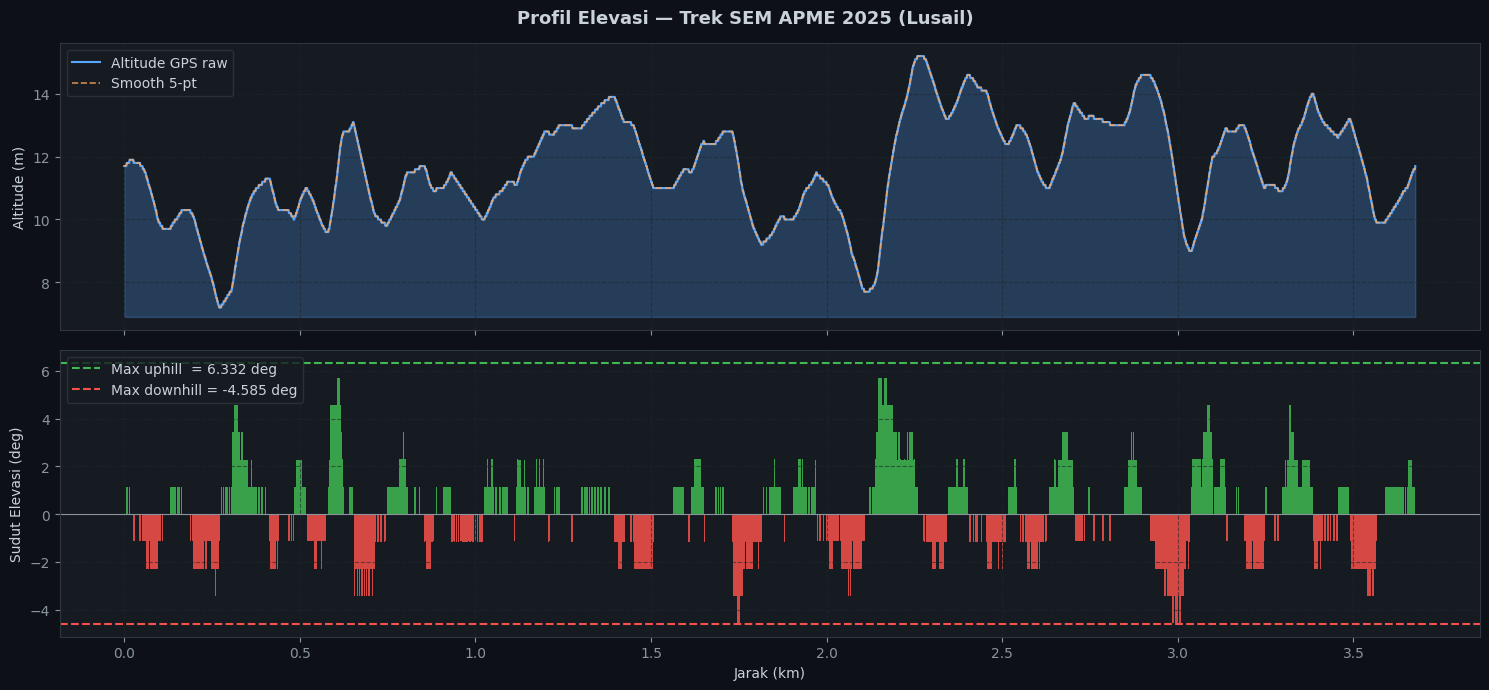

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle('Profil Elevasi — Trek SEM APME 2025 (Lusail)', fontsize=13, fontweight='bold')

ax1.fill_between(dists, alts, alts.min() - 0.3, alpha=0.25, color='#58a6ff')
ax1.plot(dists, alts,   color='#58a6ff', lw=1.5, label='Altitude GPS raw')
ax1.plot(dists, alt_sm, color='#ffa657', lw=1.2, ls='--', alpha=0.8, label='Smooth 5-pt')
ax1.set_ylabel('Altitude (m)'); ax1.legend(); ax1.grid(True)

d2   = dists[1:]
cols = ['#3fb950' if v >= 0 else '#f85149' for v in esa]
ax2.bar(d2, esa, width=0.001, color=cols, alpha=0.85)
ax2.axhline(0, color='#8b949e', lw=0.8)
ax2.axhline(float(esa.max()), color='#3fb950', lw=1.5, ls='--',
            label=f'Max uphill  = {float(esa.max()):.3f} deg')
ax2.axhline(float(esa.min()), color='#f85149', lw=1.5, ls='--',
            label=f'Max downhill = {float(esa.min()):.3f} deg')
ax2.set_ylabel('Sudut Elevasi (deg)'); ax2.set_xlabel('Jarak (km)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('../assets/plot_elevasi.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


### Heatmap Elevasi & Gradient di Peta Trek

Grafik di atas (`dists` vs `alts`/`esa`) menunjukkan elevasi *sebagai fungsi jarak*, tapi tidak *di mana* secara spasial tanjakan/turunan itu terjadi di sekitar loop. Heatmap ini memplot altitude dan grade (kemiringan, %) langsung di atas peta trek (frame `xm`/`ym` yang sama dengan peta Bagian 5), supaya segmen tanjakan/turunan curam bisa dikorelasikan langsung dengan turn dan titik Stop & Go terdekat -- relevan untuk penempatan segmen gas/glide strategi.


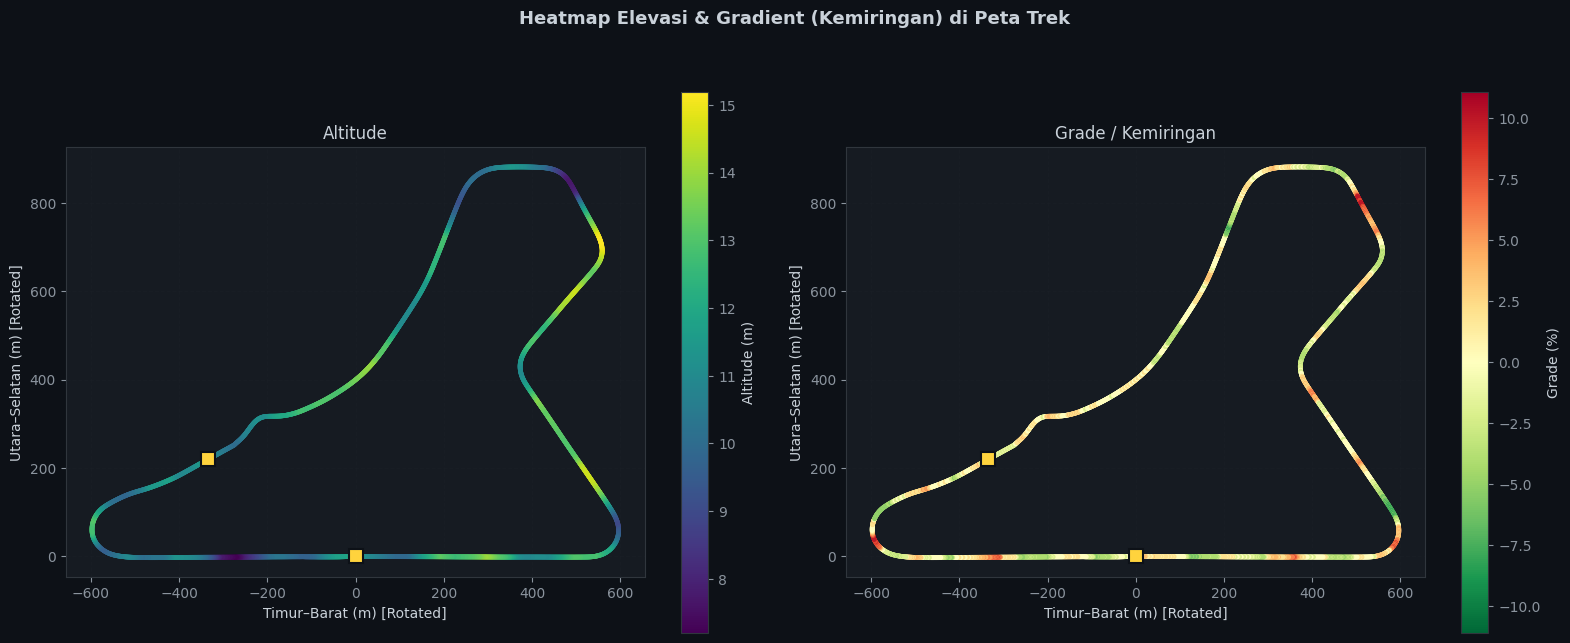

In [7]:
# Heatmap altitude & grade (gradient) trek, diplot di atas peta (frame xm/ym
# yang sama dengan peta trek Bagian 5) supaya terlihat DI MANA tanjakan/turunan
# terjadi secara spasial, bukan cuma versus jarak (Bagian 4 di atas).
fig, (axA, axG) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Heatmap Elevasi & Gradient (Kemiringan) di Peta Trek', fontsize=13, fontweight='bold')

# --- Altitude heatmap ---
scA = axA.scatter(xm, ym, c=alts, cmap='viridis', s=6, zorder=2)
axA.plot(xm, ym, color='white', lw=0.4, alpha=0.3, zorder=1)
cbA = fig.colorbar(scA, ax=axA, shrink=0.85)
cbA.set_label('Altitude (m)')
axA.set_title('Altitude')
axA.set_xlabel('Timur\u2013Barat (m) [Rotated]')
axA.set_ylabel('Utara\u2013Selatan (m) [Rotated]')
axA.set_aspect('equal'); axA.grid(True, alpha=0.2)

# --- Grade (gradient) heatmap ---
# esa (deg sudut elevasi antar titik CSV, Bagian 4) selaras dengan xm[1:]/ym[1:]
grade_pct = np.array([grade(deg) for deg in esa])
vmax = float(np.max(np.abs(grade_pct))) or 1.0
scG = axG.scatter(xm[1:], ym[1:], c=grade_pct, cmap='RdYlGn_r', vmin=-vmax, vmax=vmax, s=6, zorder=2)
axG.plot(xm, ym, color='white', lw=0.4, alpha=0.3, zorder=1)
cbG = fig.colorbar(scG, ax=axG, shrink=0.85)
cbG.set_label('Grade (%)')
axG.set_title('Grade / Kemiringan')
axG.set_xlabel('Timur\u2013Barat (m) [Rotated]')
axG.set_ylabel('Utara\u2013Selatan (m) [Rotated]')
axG.set_aspect('equal'); axG.grid(True, alpha=0.2)

# Titik STOP & GO ditandai di kedua peta untuk konteks (lihat Bagian 5)
for ax in (axA, axG):
    for si, stop_km in enumerate(STOP_LOCATIONS_KM, 1):
        idx = int(np.argmin(np.abs(dists - stop_km)))
        ax.plot(xm[idx], ym[idx], 's', color='#ffd33d', ms=10, zorder=5,
                markeredgecolor='#0d1117', markeredgewidth=1.5)

plt.tight_layout()
plt.savefig('../assets/plot_heatmap_elevasi_gradient.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 5. Analisis 11 Belokan — Kasa Circle Fitting

In [8]:
# Bearing tiap segmen (menggunakan koordinat asal GPS)
bearings = [
    get_bearing(pts[i]['lat'], pts[i]['lon'], pts[i+1]['lat'], pts[i+1]['lon'])
    for i in range(n - 1)
]

# Smooth bearing dengan 7-point circular mean
W  = 7
sb = [
    circ_mean(bearings[max(0, i - W//2) : min(len(bearings), i + W//2 + 1)])
    for i in range(len(bearings))
]

# Delta heading per step (CW = Kanan/Positif, CCW = Kiri/Negatif)
hch = [delta_heading(sb[i-1], sb[i]) for i in range(1, len(sb))]

# Curvature kumulatif dalam rolling window 30 step (~30 m)
WIN  = 30
curv = [sum(hch[max(0, i - WIN) : i + 1]) for i in range(len(hch))]

# Deteksi turn: THRESH diturunkan agar semua kandidat belokan (termasuk turn kecil) terdeteksi
THRESH  = 3.5
MIN_SEP = 15

raw = []; in_t = False; ts = 0
for i, c in enumerate(curv):
    if abs(c) >= THRESH:
        if not in_t: in_t = True; ts = i
    else:
        if in_t:
            raw.append((ts, i)); in_t = False
if in_t:
    raw.append((ts, len(curv) - 1))

# Gabungkan segmen SEARAH yang berjarak dekat (< MIN_SEP) — ini biasanya 1 turn
# yang sempat 'putus' oleh noise GPS. Segmen berlawanan arah (S-curve/esses,
# misal T3 kanan di antara T2 & T4 kiri) TETAP dipisah walau jaraknya dekat,
# supaya tidak ikut hilang/ketiban jadi 1 turn saja.
raw_turns = []
for a, b in raw:
    cum = sum(hch[a:b+1])
    if raw_turns:
        pa, pb, pcum = raw_turns[-1]
        if (a - pb) <= MIN_SEP and (pcum >= 0) == (cum >= 0):
            raw_turns[-1] = (pa, b, pcum + cum)
            continue
    raw_turns.append((a, b, cum))

# Buang zona dengan sudut kumulatif terlalu kecil untuk jadi tikungan asli —
# cuma noise GPS/sapuan landai panjang yang sempat melewati threshold deteksi
# (dikonfirmasi lewat peta trek resmi: setiap tikungan asli di sini >16deg dan
# R_min jauh di bawah 165m, vs zona palsu ~5deg dengan R tidak pernah di bawah
# ~330m dan tanpa apex asli).
MIN_REAL_TURN_ANGLE = 10.0
raw_turns = [(a, b, c) for (a, b, c) in raw_turns if abs(c) >= MIN_REAL_TURN_ANGLE]

# Penyisipan manual berbasis bukti: turn tepat setelah T1 (turn pertama yang besar)
# terlewat oleh detektor utama — trailing window-nya masih didominasi heading
# change T1 yang jauh lebih besar saat turn baru yang lebih landai ini mulai, jadi
# cumulative sum tidak pernah turun di bawah THRESH di antaranya. Dikonfirmasi lewat
# local-radius profile, citra satelit, dan cross-reference ke data GPS sirkuit F1
# Lusail penuh (trek urban SEM menyimpang dari racing line F1 sekitar 70m persis di
# titik ini — masuk ke lane berbeda). Di-scope hanya ke gap setelah turn pertama,
# tidak dijalankan generik (bagian esses lebih jauh punya turn asli berurutan tanpa
# jeda radius, versi generik akan salah memecah itu).
Rprof = local_radius_profile(xm, ym)
if len(raw_turns) >= 2:
    t1_end, t2_start = raw_turns[0][1], raw_turns[1][0]
    found = find_strongest_subturn(t1_end, t2_start, Rprof, hch)
    if found is not None and abs(found[2]) >= MIN_REAL_TURN_ANGLE:
        raw_turns.insert(1, found)
        print(f"Turn tambahan setelah T1 disisipkan: {pts[found[0]]['dk']:.3f}-{pts[found[1]]['dk']:.3f}km, "
              f"cum={found[2]:+.1f}deg")

# Filter to Top 11 Turns (buang noise/wiggle kecil, sisakan 11 turn resmi rulebook)
if len(raw_turns) > N_TURNS:
    raw_turns = sorted(sorted(raw_turns, key=lambda x: abs(x[2]), reverse=True)[:N_TURNS],
                        key=lambda x: x[0])
raw_turns = [(a, b) for a, b, _ in raw_turns]

# ── Radius per turn: R_fit whole-turn Kasa (cross-check) + Kasa fit pada GPS ASLI ─
# R_min/R_max sekarang di-fit ke titik GPS ASLI (dari KML), bukan titik CSV yang
# sudah diinterpolasi — lihat catatan di Bagian 2. Sliding-window Kasa lama (di titik
# CSV) tetap dihitung sebagai R_min_legacy untuk perbandingan.
SW    = 25
turns = []
for no, (ts, te) in enumerate(raw_turns, 1):
    buf = hch[ts : te + 1]
    xb  = xm[ts : min(te + 2, n)]
    yb  = ym[ts : min(te + 2, n)]
    if len(xb) < 4: continue

    _, _, R_fit = circle_fit_kasa(xb, yb)

    R_wins_legacy = []
    step = max(1, SW // 3)
    for j in range(0, max(1, len(xb) - SW + 1), step):
        _, _, Rw = circle_fit_kasa(xb[j:j+SW], yb[j:j+SW])
        if 3.0 < Rw < 1500:
            R_wins_legacy.append(Rw)

    u_start, u_end = u_arc[ts], u_arc[min(te + 1, n - 1)]
    n_real_in_turn = int(np.sum((real_u >= u_start) & (real_u <= u_end)))
    R_min, R_max, spread_pct, confidence = turn_radius_with_confidence(
        real_u, real_x, real_y, sigma_x_real, sigma_y_real, u_start, u_end
    )

    cum_ang = sum(buf)
    turns.append({
        'no':     no,
        's_km':   pts[min(ts + 1, n-1)]['dk'],
        'e_km':   pts[min(te + 1, n-1)]['dk'],
        'cum':    cum_ang,
        'dir':    'KANAN (CW)' if cum_ang > 0 else 'KIRI (CCW)',
        'steps':  te - ts,
        'n_real': n_real_in_turn,
        'R_fit':  R_fit if 3 < R_fit < 1500 else float('nan'),
        'R_min':  R_min,
        'R_max':  R_max,
        'confidence':   confidence,
        'spread_pct':   spread_pct,
        'R_min_legacy': min(R_wins_legacy) if R_wins_legacy else float('nan'),
        'xb': xb, 'yb': yb,
    })

print(f'Turn berhasil diproses: {len(turns)}')

Turn tambahan setelah T1 disisipkan: 0.790-0.888km, cum=-11.8deg


Turn berhasil diproses: 11


### Tabel Hasil: R_min & R_max per Turn

In [9]:
def fv(v):
    return f'{v:8.1f}' if (v == v and v < 9_999) else '     N/A'

print('=' * 136)
print('  ANALISIS 11 TURN — SEM APME 2025 | Kasa Fit pada GPS Fix ASLI + Bootstrap Confidence')
print('=' * 136)
print(f'  {"No":>3}  {"Jarak (km)":^17}  {"Arah":<12}  '
      f'{"Kumulatif":>11}  {"N_real":>6}  {"R_fit (m)":>10}  {"R_min (m)":>10}  {"R_max (m)":>10}  '
      f'{"Conv%":>6}  {"Conf":<6}  {"R_min_legacy":>12}')
print('  ' + '-' * 131)

R_fv, R_mv, R_xv, cums = [], [], [], []
for t in turns:
    ds = f"{t['s_km']:.3f} – {t['e_km']:.3f}"
    print(f"  {t['no']:>3}  {ds:^17}  {t['dir'][:12]:<12}  "
          f"{t['cum']:>+10.2f}  {t['n_real']:>6}  {fv(t['R_fit'])}  {fv(t['R_min'])}  {fv(t['R_max'])}  "
          f"{t['spread_pct']:>5.1f}%  {t['confidence']:<6}  {fv(t['R_min_legacy'])}")
    cums.append(abs(t['cum']))
    if t['R_fit'] == t['R_fit'] and t['R_fit'] < 9_999: R_fv.append(t['R_fit'])
    if t['R_min'] == t['R_min'] and t['R_min'] < 9_999: R_mv.append(t['R_min'])
    if t['R_max'] == t['R_max'] and t['R_max'] < 9_999: R_xv.append(t['R_max'])

print()
print('  RINGKASAN:')
print(f'    Sudut kumulatif per turn  : {min(cums):.1f} – {max(cums):.1f} deg')
if R_mv:
    Rmin_val = min(R_mv)
    print(f'    R_min global (apex)       : {Rmin_val:.1f} m  <- tightest point')
    v_safe   = math.sqrt(0.85 * 9.81 * Rmin_val)
    print(f'    Kecepatan aman di R_min (mu=0.85) : {v_safe:.1f} m/s = {v_safe*3.6:.1f} km/h')
    low_conf = [t['no'] for t in turns if t['confidence'] == 'Low']
    if low_conf:
        print(f'    PERHATIAN: turn {low_conf} confidence Low (spread tinggi/titik sedikit) — cek manual.')

  ANALISIS 11 TURN — SEM APME 2025 | Kasa Fit pada GPS Fix ASLI + Bootstrap Confidence
   No     Jarak (km)      Arah            Kumulatif  N_real   R_fit (m)   R_min (m)   R_max (m)   Conv%  Conf    R_min_legacy
  -----------------------------------------------------------------------------------------------------------------------------------
    1    0.517 – 0.786    KANAN (CW)       +159.00      79      73.6      52.7     141.9    2.1%  High        52.4
    2    0.791 – 0.889    KIRI (CCW)        -11.81      25     482.6     383.0     640.5   11.5%  Medium     328.4
    3    1.015 – 1.077    KIRI (CCW)        -20.05      27     168.9     111.9     188.6   90.9%  Low         90.8
    4    1.083 – 1.147    KANAN (CW)        +44.96      25      58.9      37.6      82.4    8.9%  Medium      38.3
    5    1.153 – 1.227    KIRI (CCW)        -19.07      27     208.0     135.4     353.9    7.7%  Medium     149.6
    6    1.315 – 1.442    KIRI (CCW)        -20.22      31     326.1     280.5

### Grafik Radius Min, Fit & Max per Turn

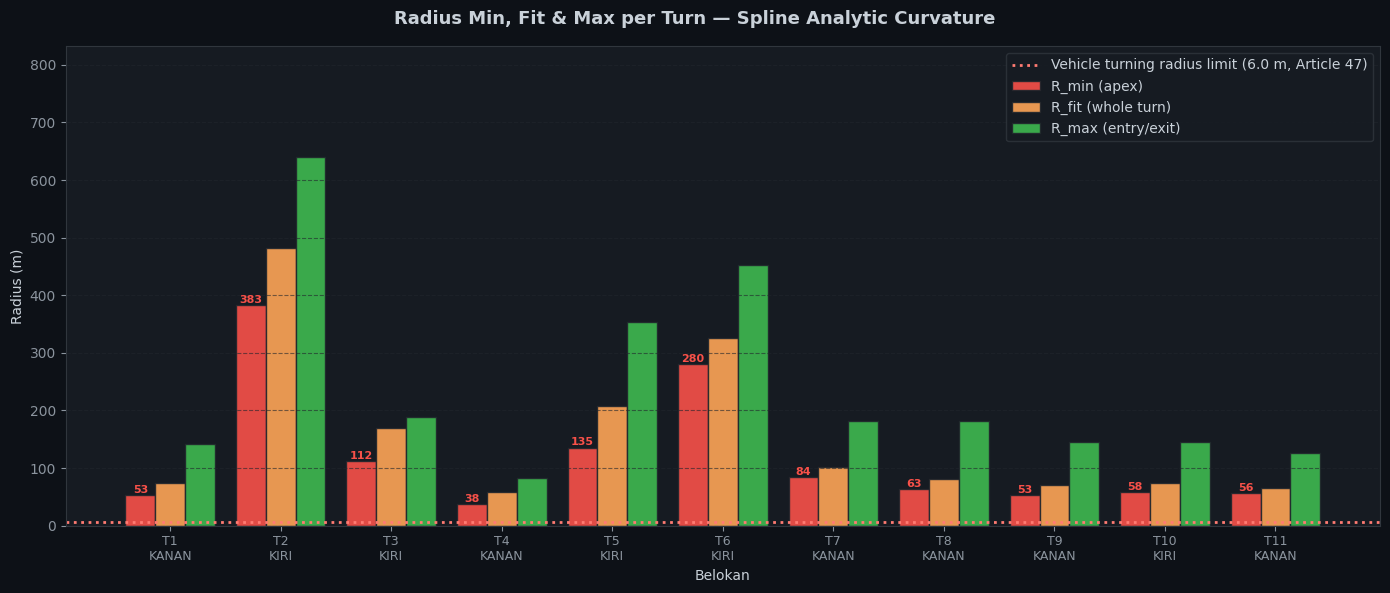

In [10]:
if turns:
    xpos = np.arange(len(turns)); w = 0.27
    Rm_p = [t['R_min'] if t['R_min'] == t['R_min'] else 0 for t in turns]
    Rf_p = [t['R_fit'] if t['R_fit'] == t['R_fit'] else 0 for t in turns]
    Rx_p = [t['R_max'] if t['R_max'] == t['R_max'] else 0 for t in turns]
    xlbl = [f"T{t['no']}\n{t['dir'].split()[0]}" for t in turns]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle('Radius Min, Fit & Max per Turn — Spline Analytic Curvature',
                 fontsize=13, fontweight='bold')

    b1 = ax.bar(xpos - w, Rm_p, width=w, label='R_min (apex)',
                color='#f85149', alpha=0.9, edgecolor='#21262d')
    b2 = ax.bar(xpos,     Rf_p, width=w, label='R_fit (whole turn)',
                color='#ffa657', alpha=0.9, edgecolor='#21262d')
    b3 = ax.bar(xpos + w, Rx_p, width=w, label='R_max (entry/exit)',
                color='#3fb950', alpha=0.9, edgecolor='#21262d')

    for bar, val in zip(b1, Rm_p):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.0f}', ha='center', va='bottom',
                    fontsize=8, color='#f85149', fontweight='bold')

    ax.axhline(MAX_VEH_RADIUS_M, color='#ff7b72', lw=2, ls=':',
               label=f'Vehicle turning radius limit ({MAX_VEH_RADIUS_M} m, Article 47)')
    ax.set_xticks(xpos); ax.set_xticklabels(xlbl, fontsize=9)
    ax.set_ylabel('Radius (m)'); ax.set_xlabel('Belokan')
    ax.legend(loc='upper right'); ax.grid(True, axis='y')
    ax.set_ylim(0, max(Rx_p + [1]) * 1.3)
    plt.tight_layout()
    plt.savefig('../assets/plot_radius_per_turn.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()


### Peta Trek — Koridor Terukur, 11 Turn & Titik Stop-and-Go

Latar peta sekarang memakai **koridor drivable hasil digitasi satelit** (Bagian 7), bukan pita "12 m konstan". Titik **STOP & GO** (Article 227: wajib berhenti penuh 2× per lap) ditandai — lokasi masih *placeholder* dari koordinat tim (start/finish + 0.95 km); lokasi resmi baru dikonfirmasi onsite di event. Catatan strategi: tiap stop = kehilangan seluruh energi kinetik → re-akselerasi dari 0, jadi penempatan segmen akselerasi GA harus mengikuti kedua titik ini.

[QA clamp] width: 11.0 – 13.0 m  (capped to [11.0, 13.0] m)


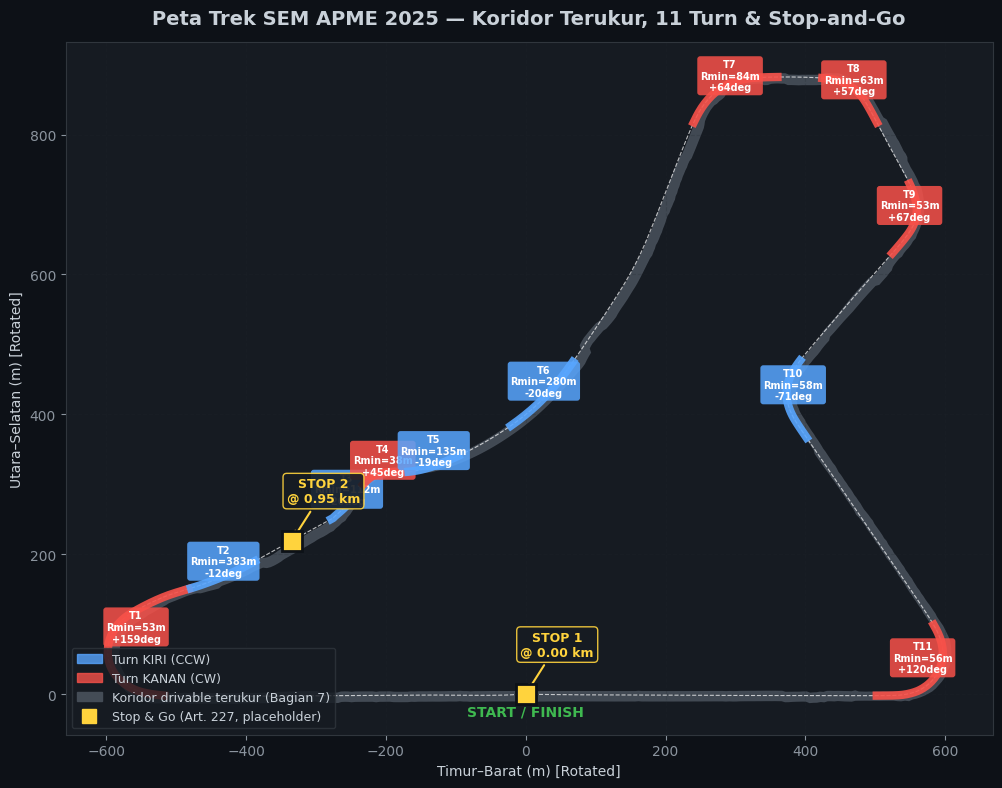

In [11]:
import pandas as pd

# Koridor terukur (Bagian 7) di frame peta yang sama (origin la0/lo0 + rotasi theta).
_wd = pd.read_csv('../data/track_edges_imagery.csv')

# ── QA Width Constraints (manual field knowledge) ────────────────────────────
# Field observation: drivable width on this SEM Lusail urban route cannot
# exceed 13.0 m (wide F1 aprons are not fully drivable) and the narrowest
# passable section is ≥ 11.0 m.  Satellite CV occasionally over-/under-detects
# edge markings; we apply symmetric proportional scaling to preserve the
# left/right split and keep the centerline fixed.
W_MAX, W_MIN = 13.0, 11.0   # metres

_mask_hi = _wd['width_m'] > W_MAX
_sc_hi   = W_MAX / _wd.loc[_mask_hi, 'width_m']
_wd.loc[_mask_hi, 'w_left_m']  *= _sc_hi
_wd.loc[_mask_hi, 'w_right_m'] *= _sc_hi
_wd.loc[_mask_hi, 'width_m']    = W_MAX

_mask_lo = _wd['width_m'] < W_MIN
_sc_lo   = W_MIN / _wd.loc[_mask_lo, 'width_m']
_wd.loc[_mask_lo, 'w_left_m']  *= _sc_lo
_wd.loc[_mask_lo, 'w_right_m'] *= _sc_lo
_wd.loc[_mask_lo, 'width_m']    = W_MIN

print(f'[QA clamp] width: {_wd.width_m.min():.1f} – {_wd.width_m.max():.1f} m  '
      f'(capped to [{W_MIN}, {W_MAX}] m)')
_MLAT = 111132.954 - 559.822 * math.cos(2 * math.radians(la0))
_MLON = 111412.84 * math.cos(math.radians(la0))

def _map_xy(lat_a, lon_a):
    _x = (np.asarray(lon_a) - lo0) * _MLON
    _y = (np.asarray(lat_a) - la0) * _MLAT
    return _x * math.cos(theta) - _y * math.sin(theta), _x * math.sin(theta) + _y * math.cos(theta)

_cx = (_wd.lon.to_numpy() - lo0) * _MLON
_cy = (_wd.lat.to_numpy() - la0) * _MLAT
_tx, _ty = np.gradient(_cx), np.gradient(_cy)
_tn = np.hypot(_tx, _ty)
_nx, _ny = -_ty / _tn, _tx / _tn
_xL, _yL = _map_xy(_wd.lat + (_wd.w_left_m * _ny) / _MLAT, _wd.lon + (_wd.w_left_m * _nx) / _MLON)
_xR, _yR = _map_xy(_wd.lat - (_wd.w_right_m * _ny) / _MLAT, _wd.lon - (_wd.w_right_m * _nx) / _MLON)

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Peta Trek SEM APME 2025 — Koridor Terukur, 11 Turn & Stop-and-Go',
             fontsize=14, fontweight='bold')

# koridor drivable sebenarnya sebagai latar
ax.fill(np.concatenate([_xL, _xR[::-1]]), np.concatenate([_yL, _yR[::-1]]),
        color='#444c56', alpha=0.95, zorder=1)
ax.plot(xm, ym, color='white', lw=0.8, ls='--', alpha=0.7, zorder=2)  # garis GPS Shell

for t in turns:
    col = '#58a6ff' if 'KIRI' in t['dir'] else '#f85149'
    ax.plot(t['xb'], t['yb'], color=col, lw=6, alpha=0.9, zorder=3)
    mx, my = float(np.mean(t['xb'])), float(np.mean(t['yb']))
    Rm = t['R_min'] if t['R_min'] == t['R_min'] else 0.0
    ax.annotate(
        f"T{t['no']}\nRmin={Rm:.0f}m\n{t['cum']:+.0f}deg",
        xy=(mx, my), fontsize=7, ha='center', color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=col, alpha=0.85, edgecolor='none'),
    )

# ── Titik STOP & GO (Article 227 — 2x per lap, wajib berhenti penuh) ──
for si, stop_km in enumerate(STOP_LOCATIONS_KM, 1):
    idx = int(np.argmin(np.abs(dists - stop_km)))
    ax.plot(xm[idx], ym[idx], 's', color='#ffd33d', ms=14, zorder=7,
            markeredgecolor='#0d1117', markeredgewidth=2)
    ax.annotate(f'STOP {si}\n@ {stop_km:.2f} km', xy=(xm[idx], ym[idx]),
                xytext=(xm[idx] + 45, ym[idx] + 55),
                arrowprops=dict(arrowstyle='->', color='#ffd33d', lw=1.5),
                fontsize=9, color='#ffd33d', fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22',
                          alpha=0.9, edgecolor='#ffd33d'))

ax.plot(xm[0], ym[0], 'o', color='#3fb950', ms=12, zorder=6)
ax.annotate('START / FINISH', xy=(xm[0], ym[0] - 30), ha='center',
            color='#3fb950', fontweight='bold')

pL = mpatches.Patch(color='#58a6ff', alpha=0.8, label='Turn KIRI (CCW)')
pR = mpatches.Patch(color='#f85149', alpha=0.8, label='Turn KANAN (CW)')
pW = mpatches.Patch(color='#444c56', label='Koridor drivable terukur (Bagian 7)')
pS = plt.Line2D([], [], marker='s', color='#ffd33d', ls='', ms=10,
                label='Stop & Go (Art. 227, placeholder)')
ax.legend(handles=[pL, pR, pW, pS], loc='lower left', fontsize=9)

ax.set_xlabel('Timur–Barat (m) [Rotated]')
ax.set_ylabel('Utara–Selatan (m) [Rotated]')
ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../assets/plot_peta_trek.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. Ringkasan Final Vehicle Dynamics

In [12]:
print('=' * 65)
print('  RINGKASAN FINAL — PARTNER VEHICLE DYNAMICS & STRATEGY')
print('=' * 65)
print('  ELEVASI (real-fix spline):')
print(f"    Max uphill  : {elev_result['uphill_deg']:+.3f} deg  (grade {grade(elev_result['uphill_deg']):+.2f}%) "
      f"[{elev_result['uphill_conf']}]")
print(f"    Max downhill: {elev_result['downhill_deg']:+.3f} deg  (grade {grade(elev_result['downhill_deg']):+.2f}%) "
      f"[{elev_result['downhill_conf']}]")
print(f'  BELOKAN ({len(turns)} / {N_TURNS} turn official):')
print(f'    Sudut kumulatif : {min(cums):.1f} – {max(cums):.1f} deg')
if R_mv:
    print(f'    R_min (apex)    : {min(R_mv):.1f} m')
    vs = math.sqrt(0.85 * 9.81 * min(R_mv))
    print(f'    V aman @ R_min  : {vs:.1f} m/s = {vs*3.6:.1f} km/h (mu=0.85)')
print()
print('  LEBAR TREK (terukur per titik — Bagian 7):')
print(f'    min {_wd.width_m.min():.1f} m @ {_wd.loc[_wd.width_m.idxmin(), "station_shell_m"]/1000:.2f} km | '
      f'median {_wd.width_m.median():.1f} m | max {_wd.width_m.max():.1f} m')
print(f'    VEH WIDTH   : {VEHICLE_WIDTH_M*1000:.0f} mm')
print(f'    MANUVER ROOM di titik TERSEMPIT: '
      f'{(_wd.width_m.min() - VEHICLE_WIDTH_M)/2:.2f} m per sisi')
print()
print(f'  STOP & GO (Art. 227, 2x/lap, PLACEHOLDER sampai konfirmasi onsite):')
for si, sk in enumerate(STOP_LOCATIONS_KM, 1):
    print(f'    STOP {si} @ {sk:.2f} km')

  RINGKASAN FINAL — PARTNER VEHICLE DYNAMICS & STRATEGY
  ELEVASI (real-fix spline):
    Max uphill  : +5.538 deg  (grade +9.70%) [High]
    Max downhill: -4.429 deg  (grade -7.75%) [High]
  BELOKAN (11 / 11 turn official):
    Sudut kumulatif : 11.8 – 159.0 deg
    R_min (apex)    : 37.6 m
    V aman @ R_min  : 17.7 m/s = 63.7 km/h (mu=0.85)

  LEBAR TREK (terukur per titik — Bagian 7):
    min 11.0 m @ 0.83 km | median 13.0 m | max 13.0 m
    VEH WIDTH   : 1250 mm
    MANUVER ROOM di titik TERSEMPIT: 4.88 m per sisi

  STOP & GO (Art. 227, 2x/lap, PLACEHOLDER sampai konfirmasi onsite):
    STOP 1 @ 0.00 km
    STOP 2 @ 0.95 km


## 7. Lebar Trek Per Titik — Digitasi Citra Satelit (2026-07)

Menggantikan asumsi **12 m konstan**. Lebar drivable diukur per 5 m dari citra satelit **Esri World Imagery z19 (~0,27 m/px)**: deteksi tepi aspal pada profil warna tegak lurus + QA visual seluruh 37 strip map + koreksi manual (pipeline: `scripts/track_width_digitization/`, data: `data/track_edges_imagery.csv`). Divalidasi silang dengan pengukuran manual Google Earth (mis. 11,47 m di titik merge jalan akses — cocok dengan data).

**Definisi tepi (konservatif):** curb, runoff bercat merah, pasir, dan pembatas TIDAK dihitung drivable; garis putih dianggap bisa dilewati bila aspal menerus di baliknya. Lajur biru (cool-pavement) di seksi jalan akses 1,15–1,45 km **termasuk drivable** (diverifikasi manual dari citra terbaru).

**Temuan kunci:**
- Lebar: **min 6,6 m / median 13,3 m / max 26,9 m**. Titik tersempit = jalan akses dua lajur di km 1,10–1,14 (memang sempit, bukan artefak).
- **Garis GPS Shell bukan tengah lintasan**: median geser ~4 m, max ~10 m — di beberapa seksi dia menempel tepi dan memotong 2 tikungan kart track. Centerline baru = titik tengah tepi kiri–kanan (loop 3682 m).
- Rute campuran: main straight F1 → kompleks T1 → jalan akses sempit (7–11,5 m) → merge ke seksi lebar (~27 m) → kart circuit (10–12 m) → hairpin → kembali ke main straight.

> Optimizer driving line (Bagian 8) mengurangi sendiri setengah lebar kendaraan (0,61 m) + margin keselamatan dari lebar ini.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load hasil digitasi lebar trek dari citra satelit (Esri World Imagery z19)
wd = pd.read_csv('../data/track_edges_imagery.csv')

# ── QA Width Constraints (manual field knowledge) ────────────────────────────
# Field observation: drivable width on this SEM Lusail urban route cannot
# exceed 13.0 m (wide F1 aprons are not fully drivable) and the narrowest
# passable section is ≥ 11.0 m.  Satellite CV occasionally over-/under-detects
# edge markings; we apply symmetric proportional scaling to preserve the
# left/right split and keep the centerline fixed.
W_MAX, W_MIN = 13.0, 11.0   # metres

mask_hi = wd['width_m'] > W_MAX
sc_hi   = W_MAX / wd.loc[mask_hi, 'width_m']
wd.loc[mask_hi, 'w_left_m']  *= sc_hi
wd.loc[mask_hi, 'w_right_m'] *= sc_hi
wd.loc[mask_hi, 'width_m']    = W_MAX

mask_lo = wd['width_m'] < W_MIN
sc_lo   = W_MIN / wd.loc[mask_lo, 'width_m']
wd.loc[mask_lo, 'w_left_m']  *= sc_lo
wd.loc[mask_lo, 'w_right_m'] *= sc_lo
wd.loc[mask_lo, 'width_m']    = W_MIN

print(f'[QA clamp] width: {wd.width_m.min():.1f} – {wd.width_m.max():.1f} m  '
      f'(capped to [{W_MIN}, {W_MAX}] m)')

w_min = wd.width_m.min()
print('=' * 70)
print('  LEBAR TREK PER TITIK — HASIL DIGITASI CITRA SATELIT')
print('=' * 70)
print(f'  Stasiun         : {len(wd)} titik @ 5 m')
print(f'  Panjang loop    : {wd.station_new_m.iloc[-1]:.0f} m (centerline baru, midpoint tepi)')
print(f'  Lebar min       : {w_min:.1f} m  @ {wd.loc[wd.width_m.idxmin(), "station_shell_m"]:.0f} m (jalan akses 2 lajur)')
print(f'  Lebar median    : {wd.width_m.median():.1f} m')
print(f'  Lebar max       : {wd.width_m.max():.1f} m  @ {wd.loc[wd.width_m.idxmax(), "station_shell_m"]:.0f} m')
print(f'  Lebar p5 – p95  : {wd.width_m.quantile(0.05):.1f} – {wd.width_m.quantile(0.95):.1f} m')
print()
frac_below = (wd.width_m < 12.0).mean() * 100
print(f'  vs ASUMSI LAMA 12 m konstan:')
print(f'    {frac_below:.0f}% titik trek LEBIH SEMPIT dari 12 m')
print(f'    Bagian tersempit ({w_min:.1f} m) hanya {w_min/12*100:.0f}% dari asumsi lama')
print()
shift = wd.centerline_shift_m.abs()
print(f'  Pergeseran centerline (GPS Shell vs tengah koridor sebenarnya):')
print(f'    median {shift.median():.1f} m | p95 {shift.quantile(0.95):.1f} m | max {shift.max():.1f} m')
print(f'    -> garis GPS Shell BUKAN tengah lintasan: menempel tepi di beberapa')
print(f'       seksi dan memotong 2 tikungan kart track.')

[QA clamp] width: 11.0 – 13.0 m  (capped to [11.0, 13.0] m)
  LEBAR TREK PER TITIK — HASIL DIGITASI CITRA SATELIT
  Stasiun         : 734 titik @ 5 m
  Panjang loop    : 3682 m (centerline baru, midpoint tepi)
  Lebar min       : 11.0 m  @ 830 m (jalan akses 2 lajur)
  Lebar median    : 13.0 m
  Lebar max       : 13.0 m  @ 0 m
  Lebar p5 – p95  : 11.0 – 13.0 m

  vs ASUMSI LAMA 12 m konstan:
    30% titik trek LEBIH SEMPIT dari 12 m
    Bagian tersempit (11.0 m) hanya 92% dari asumsi lama

  Pergeseran centerline (GPS Shell vs tengah koridor sebenarnya):
    median 3.8 m | p95 8.5 m | max 10.4 m
    -> garis GPS Shell BUKAN tengah lintasan: menempel tepi di beberapa
       seksi dan memotong 2 tikungan kart track.


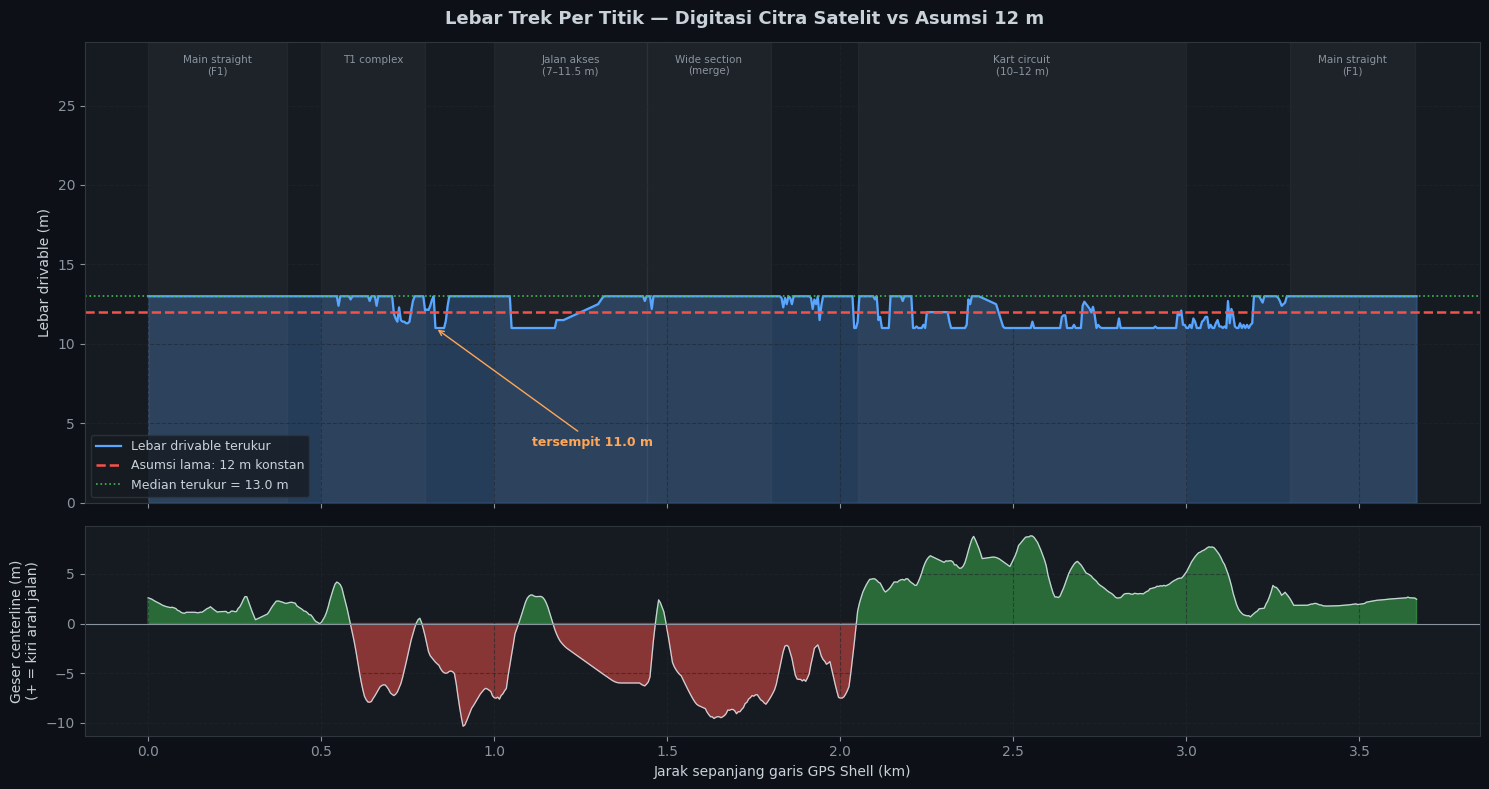

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2.2, 1]})
fig.suptitle('Lebar Trek Per Titik — Digitasi Citra Satelit vs Asumsi 12 m',
             fontsize=13, fontweight='bold')

s_km = wd.station_shell_m / 1000.0
ax1.fill_between(s_km, wd.width_m, 0, alpha=0.25, color='#58a6ff')
ax1.plot(s_km, wd.width_m, color='#58a6ff', lw=1.6, label='Lebar drivable terukur')
ax1.axhline(12.0, color='#f85149', lw=1.8, ls='--', label='Asumsi lama: 12 m konstan')
ax1.axhline(wd.width_m.median(), color='#3fb950', lw=1.2, ls=':',
            label=f'Median terukur = {wd.width_m.median():.1f} m')

# tandai zona-zona karakteristik permukaan rute
zones = [
    (0.00, 0.40, 'Main straight\n(F1)'),
    (0.50, 0.80, 'T1 complex'),
    (1.00, 1.44, 'Jalan akses\n(7–11.5 m)'),
    (1.44, 1.80, 'Wide section\n(merge)'),
    (2.05, 3.00, 'Kart circuit\n(10–12 m)'),
    (3.30, 3.66, 'Main straight\n(F1)'),
]
for z0, z1, lbl in zones:
    ax1.axvspan(z0, z1, color='#8b949e', alpha=0.07)
    ax1.text((z0 + z1) / 2, 28.2, lbl, ha='center', va='top', fontsize=7.5,
             color='#8b949e')

i_min = wd.width_m.idxmin()
ax1.annotate(f'tersempit {wd.width_m.min():.1f} m',
             xy=(s_km[i_min], wd.width_m.min()),
             xytext=(s_km[i_min] + 0.28, 3.6),
             arrowprops=dict(arrowstyle='->', color='#ffa657'),
             fontsize=9, color='#ffa657', fontweight='bold')
ax1.set_ylabel('Lebar drivable (m)')
ax1.set_ylim(0, 29)
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True)

ax2.fill_between(s_km, wd.centerline_shift_m, 0,
                 where=wd.centerline_shift_m >= 0, color='#3fb950', alpha=0.5, interpolate=True)
ax2.fill_between(s_km, wd.centerline_shift_m, 0,
                 where=wd.centerline_shift_m < 0, color='#f85149', alpha=0.5, interpolate=True)
ax2.plot(s_km, wd.centerline_shift_m, color='#c9d1d9', lw=0.9)
ax2.axhline(0, color='#8b949e', lw=0.8)
ax2.set_ylabel('Geser centerline (m)\n(+ = kiri arah jalan)')
ax2.set_xlabel('Jarak sepanjang garis GPS Shell (km)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('../assets/plot_lebar_trek.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

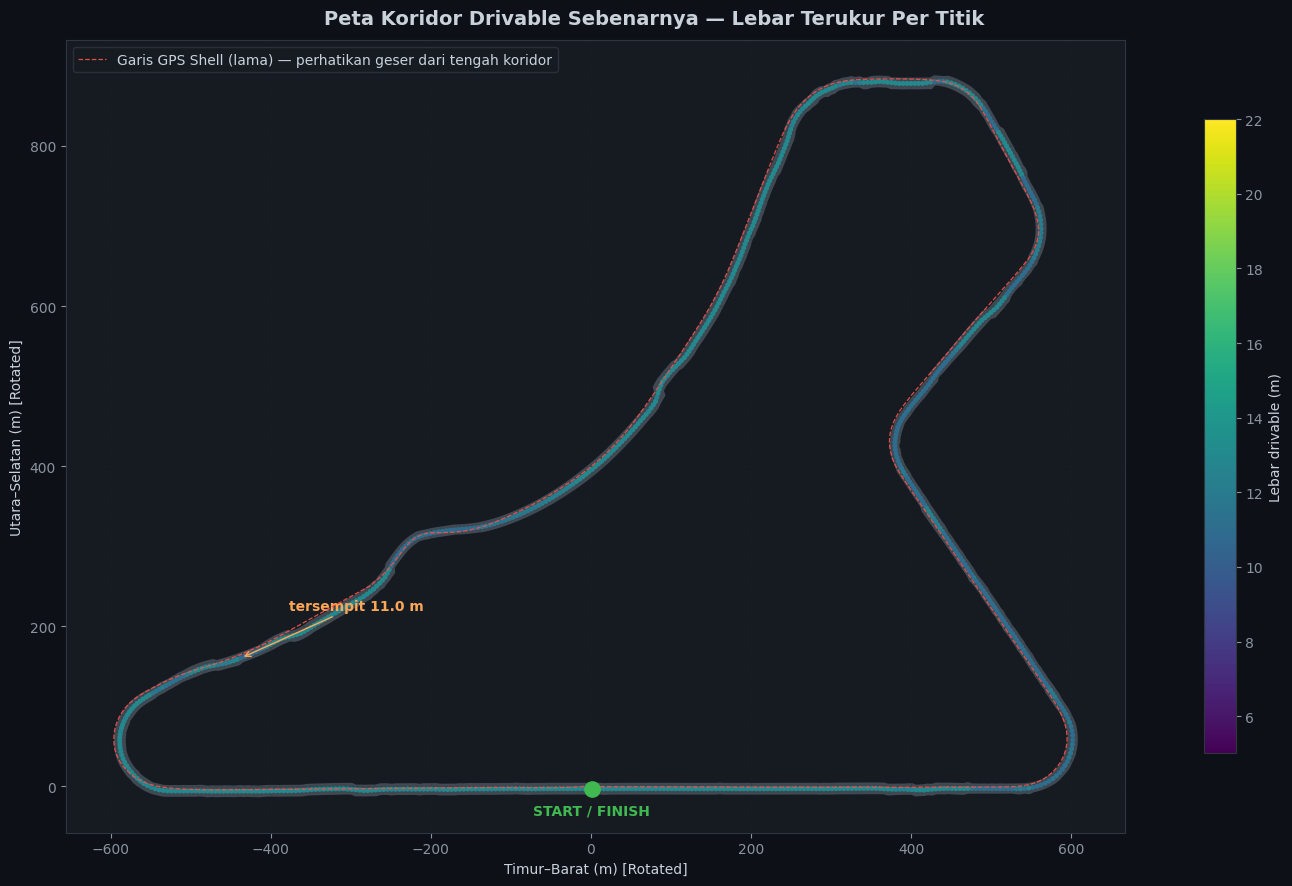

In [15]:
import math

# Peta koridor drivable sebenarnya (menggantikan garis abu-abu "12 m" konstan).
# Self-contained: bangun ulang frame XY lokal + rotasi 61.22 deg yang sama
# dengan peta di Bagian 5, dengan origin = titik pertama CSV Shell.
_shell = pd.read_csv('../data/sem_apme_2025-track_coordinates.csv', sep='\t')
_la0, _lo0 = float(_shell.latitude[0]), float(_shell.longitude[0])
_MLAT = 111132.954 - 559.822 * math.cos(2 * math.radians(_la0))
_MLON = 111412.84 * math.cos(math.radians(_la0))
_th = math.radians(61.22)

def _to_map_xy(lat, lon):
    x = (np.asarray(lon) - _lo0) * _MLON
    y = (np.asarray(lat) - _la0) * _MLAT
    return x * math.cos(_th) - y * math.sin(_th), x * math.sin(_th) + y * math.cos(_th)

# Normal arah-kiri dari centerline baru (gradien sepanjang lintasan)
cx = (wd.lon.to_numpy() - _lo0) * _MLON
cy = (wd.lat.to_numpy() - _la0) * _MLAT
tx, ty = np.gradient(cx), np.gradient(cy)
tn = np.hypot(tx, ty); tx, ty = tx / tn, ty / tn
nx, ny = -ty, tx

latL = wd.lat + (wd.w_left_m * ny) / _MLAT
lonL = wd.lon + (wd.w_left_m * nx) / _MLON
latR = wd.lat - (wd.w_right_m * ny) / _MLAT
lonR = wd.lon - (wd.w_right_m * nx) / _MLON

xC, yC = _to_map_xy(wd.lat, wd.lon)
xL, yL = _to_map_xy(latL, lonL)
xR, yR = _to_map_xy(latR, lonR)
xS, yS = _to_map_xy(_shell.latitude, _shell.longitude)

fig, ax = plt.subplots(figsize=(16, 9))
fig.suptitle('Peta Koridor Drivable Sebenarnya — Lebar Terukur Per Titik',
             fontsize=14, fontweight='bold')

# polygon koridor (tepi kiri + tepi kanan dibalik)
poly_x = np.concatenate([xL, xR[::-1]])
poly_y = np.concatenate([yL, yR[::-1]])
ax.fill(poly_x, poly_y, color='#444c56', alpha=0.9, zorder=1)

sc = ax.scatter(xC, yC, c=wd.width_m, cmap='viridis', s=7, zorder=3,
                vmin=5, vmax=22)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Lebar drivable (m)')

ax.plot(xS, yS, color='#f85149', lw=0.9, ls='--', alpha=0.9, zorder=4,
        label='Garis GPS Shell (lama) — perhatikan geser dari tengah koridor')
ax.plot(xC[0], yC[0], 'o', color='#3fb950', ms=11, zorder=6)
ax.annotate('START / FINISH', xy=(xC[0], yC[0] - 32), ha='center',
            color='#3fb950', fontweight='bold')

i_min = int(wd.width_m.idxmin())
ax.annotate(f'tersempit {wd.width_m.min():.1f} m',
            xy=(xC[i_min], yC[i_min]), xytext=(xC[i_min] + 60, yC[i_min] + 60),
            arrowprops=dict(arrowstyle='->', color='#ffa657'),
            fontsize=10, color='#ffa657', fontweight='bold')

ax.set_xlabel('Timur–Barat (m) [Rotated]')
ax.set_ylabel('Utara–Selatan (m) [Rotated]')
ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../assets/plot_peta_koridor.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 8. Driving Line Optimal — Shortest Path QP

Garis mengemudi optimal-energi (**bukan** racing line minimum-time). Alasan objektif: di kecepatan SEM (25–50 km/h) loss dominan — rolling resistance dan aero — keduanya proporsional terhadap **jarak tempuh**, bukan waktu. Jadi garis optimal ≈ **jalur terpendek** di dalam koridor drivable, bukan minimum-curvature klasik (yang memperpanjang lintasan demi radius besar).

**Formulasi** (mengikuti `opt_shortest_path` dari TUM global trajectory optimizer, diimplementasi ulang di `digital_twin/racing_line.py` dengan scipy bounded least-squares):
- Variabel: offset lateral α per stasiun 5 m dari centerline terukur; batas α = tepi terukur − (½ lebar kendaraan 0,61 m + margin 0,40 m).
- Objektif: panjang lintasan (surrogate kuadratik, spacing-aware) + regularizer kelengkungan λ=300 supaya tidak menikung patah di apex (kink → cornering scrub naik & v_safe turun).
- Loop tertutup (wraparound), diselesaikan sebagai sparse bounded linear least squares.

**Hasil:** panjang lap **3625,5 m** vs centerline 3682,5 m → **hemat 57 m/lap (228 m per attempt 4 lap, ~1,5%)**. Radius minimum di garis: **33,9 m** (jauh di atas batas belok kendaraan 6 m, Art. 47); v_safe minimum ~60,5 km/h — di atas puncak pulse DP (~50 km/h), jadi cornering tidak pernah membatasi strategi kecepatan. Sudah diverifikasi visual di atas citra satelit (garis memeluk sisi dalam tikungan dengan clearance, tidak pernah keluar koridor).

Data: `data/racing_line.csv` | Modul: `python -m digital_twin.racing_line`

**Update (2026-07-21):** garis ini sekarang benar-benar dipakai sebagai track oleh DP/GA/PSO/CMA-ES di `digital_twin/optimize_*.py` (lewat `track.build_racing_line_profile()`), bukan cuma analisis geometri berdiri sendiri. Dampak H2 terukur (bukan estimasi proporsional-jarak): DP +5.5%, GA +1.4%, PSO +6.3%, CMA-ES +4.2% -- detail lengkap di `notebooks/Racing_Line_Strategy_Comparison.ipynb`.

**Update (2026-07-24):** panjang di atas sekarang dihitung dari koridor lebar yang sudah di-QA (11–13 m, `digital_twin.track.apply_width_qa_clamp`) -- sebelumnya `racing_line.py` membaca lebar mentah hasil digitasi citra (sampai 26,9 m di sekitar km 1,47, titik merge ke apron F1) tanpa koreksi QA yang sama yang sudah dipakai notebook ini sejak Bagian 7. Racing line diregenerasi ulang; hasil bergeser tipis (3626,5 m -> 3625,5 m) karena anomali lebar itu cuma di beberapa stasiun lokal.


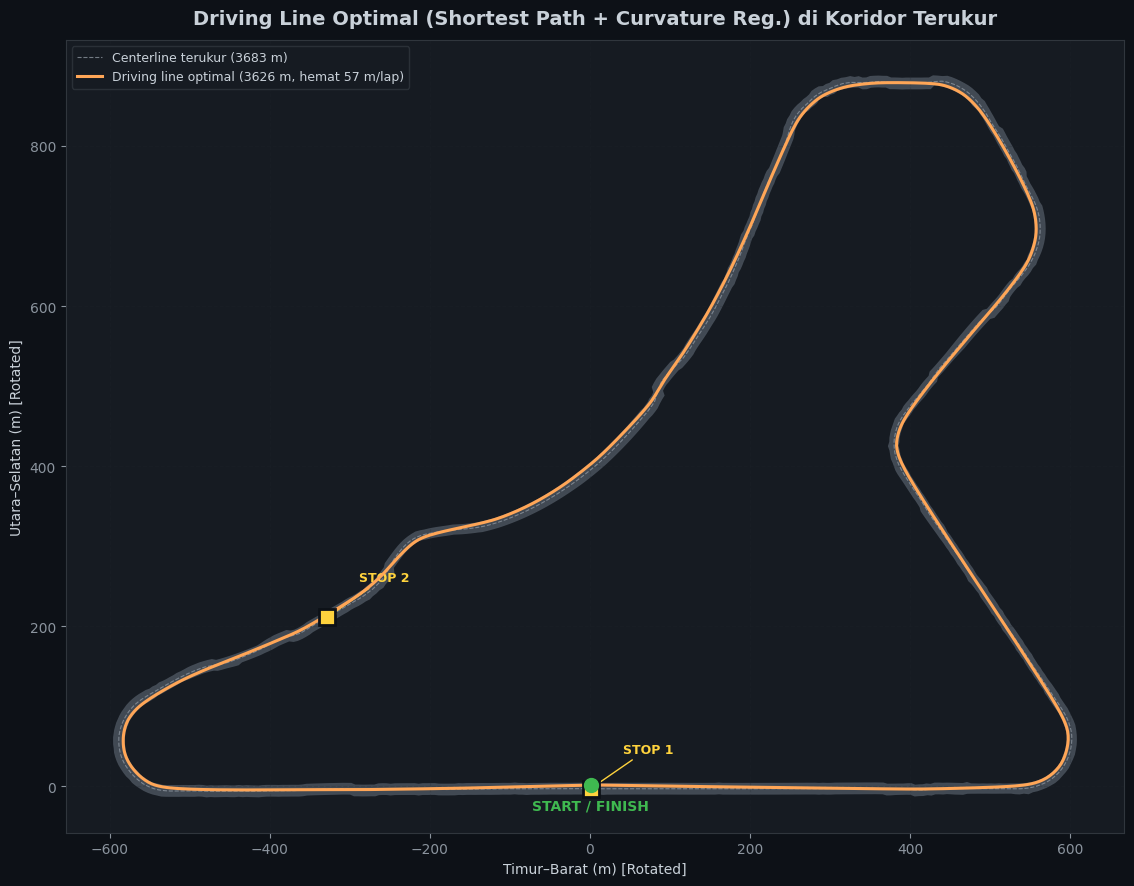

In [16]:
# Peta driving line di dalam koridor (frame rotasi sama dengan peta Bagian 5/7)
rl = pd.read_csv('../data/racing_line.csv')
xRL, yRL = _to_map_xy(rl.lat, rl.lon)

fig, ax = plt.subplots(figsize=(16, 9))
fig.suptitle('Driving Line Optimal (Shortest Path + Curvature Reg.) di Koridor Terukur',
             fontsize=14, fontweight='bold')

ax.fill(poly_x, poly_y, color='#444c56', alpha=0.95, zorder=1)
_center_len_m = float(np.hypot(np.diff(np.append(xC, xC[0])), np.diff(np.append(yC, yC[0]))).sum())
_rlx, _rly = rl.x_m.to_numpy(), rl.y_m.to_numpy()
_rl_len_m = float(np.hypot(np.diff(np.append(_rlx, _rlx[0])), np.diff(np.append(_rly, _rly[0]))).sum())
_saved_m = _center_len_m - _rl_len_m
ax.plot(xC, yC, color='#8b949e', lw=0.8, ls='--', alpha=0.8, zorder=2,
        label=f'Centerline terukur ({_center_len_m:.0f} m)')
ax.plot(np.append(xRL, xRL[0]), np.append(yRL, yRL[0]), color='#ffa657', lw=2.2,
        zorder=4, label=f'Driving line optimal ({_rl_len_m:.0f} m, hemat {_saved_m:.0f} m/lap)')

# stop & go juga relevan untuk garis ini
for si, stop_km in enumerate(STOP_LOCATIONS_KM, 1):
    j = int(np.argmin(np.abs(wd.station_shell_m / 1000.0 - stop_km)))
    ax.plot(xC[j], yC[j], 's', color='#ffd33d', ms=12, zorder=6,
            markeredgecolor='#0d1117', markeredgewidth=2)
    ax.annotate(f'STOP {si}', xy=(xC[j], yC[j]), xytext=(xC[j] + 40, yC[j] + 45),
                arrowprops=dict(arrowstyle='->', color='#ffd33d'),
                fontsize=9, color='#ffd33d', fontweight='bold')

ax.plot(xRL[0], yRL[0], 'o', color='#3fb950', ms=10, zorder=6)
ax.annotate('START / FINISH', xy=(xRL[0], yRL[0] - 30), ha='center',
            color='#3fb950', fontweight='bold')

ax.set_xlabel('Timur–Barat (m) [Rotated]')
ax.set_ylabel('Utara–Selatan (m) [Rotated]')
ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/plot_driving_line.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

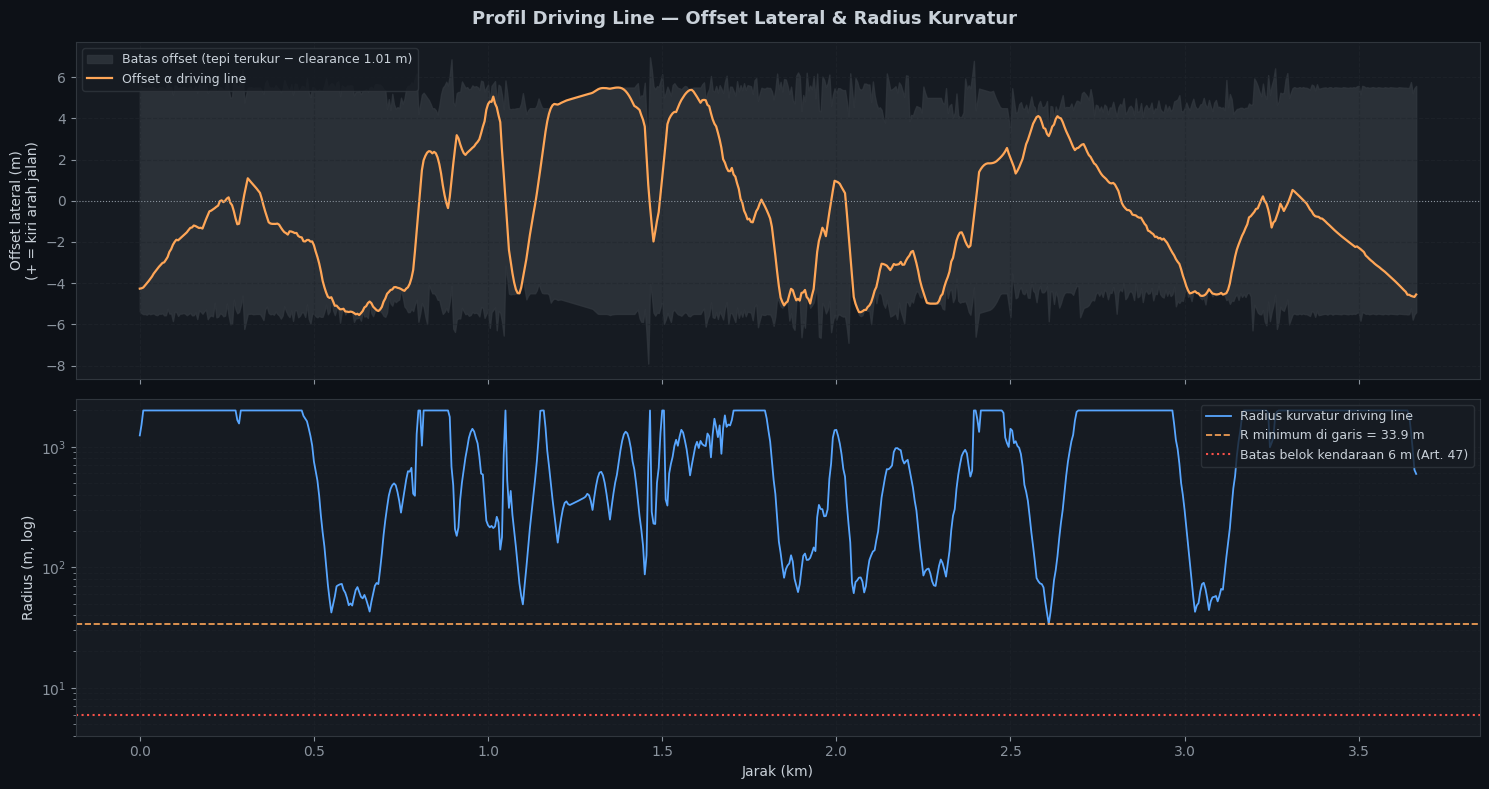

Panjang driving line : 3626 m  (centerline 3683 m -> hemat ~57 m/lap, ~228 m per attempt)
Radius min           : 33.9 m  | v_safe min: 60.5 km/h (mu=0.85)
Offset max kiri/kanan: +5.5 / -5.5 m


In [17]:
# Profil driving line: offset lateral di dalam batas koridor + radius kurvatur
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Profil Driving Line — Offset Lateral & Radius Kurvatur', fontsize=13, fontweight='bold')

s_rl_km = rl.station_shell_m / 1000.0
CLEAR = 1.01  # ½ lebar kendaraan + margin (lihat digital_twin/racing_line.py)
lo_b = -(wd.w_right_m - CLEAR)
hi_b = wd.w_left_m - CLEAR

ax1.fill_between(s_rl_km, lo_b, hi_b, color='#30363d', alpha=0.8,
                 label='Batas offset (tepi terukur − clearance 1.01 m)')
ax1.plot(s_rl_km, rl.alpha_m, color='#ffa657', lw=1.6, label='Offset α driving line')
ax1.axhline(0, color='#8b949e', lw=0.8, ls=':')
ax1.set_ylabel('Offset lateral (m)\n(+ = kiri arah jalan)')
ax1.legend(loc='upper left', fontsize=9); ax1.grid(True)

Rplot = np.minimum(rl.radius_m, 2000.0)
ax2.semilogy(s_rl_km, Rplot, color='#58a6ff', lw=1.3, label='Radius kurvatur driving line')
_rmin_line = float(rl.radius_m.min())
ax2.axhline(_rmin_line, color='#ffa657', lw=1.2, ls='--', label=f'R minimum di garis = {_rmin_line:.1f} m')
ax2.axhline(6.0, color='#f85149', lw=1.5, ls=':', label='Batas belok kendaraan 6 m (Art. 47)')
ax2.set_ylabel('Radius (m, log)'); ax2.set_xlabel('Jarak (km)')
ax2.set_ylim(4, 2500)
ax2.legend(loc='upper right', fontsize=9); ax2.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.savefig('../assets/plot_driving_line_profil.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Panjang driving line : {_rl_len_m:.0f} m  (centerline {_center_len_m:.0f} m -> hemat ~{_saved_m:.0f} m/lap, ~{4*_saved_m:.0f} m per attempt)')
print(f'Radius min           : {rl.radius_m.min():.1f} m  | v_safe min: {rl.v_safe_kmh.min():.1f} km/h (mu=0.85)')
print(f'Offset max kiri/kanan: {rl.alpha_m.max():+.1f} / {rl.alpha_m.min():+.1f} m')

## 9. Analisis Jarak Segmen — Turn & Straight Distance Map

Bagian ini menghitung **jarak setiap turn (T1–T11)** dan **jarak setiap straight** di antara turn,
lalu menampilkannya langsung di peta trek (racing line).

- **Turn distance** = jarak sesungguhnya sepanjang **optimum racing line** (`s_m`) dari awal sampai akhir turn
- **Straight distance** = jarak sepanjang optimum racing line dari akhir satu turn ke awal turn berikutnya
- Turn boundaries diambil dari analisis belokan (`Data_Final.csv`), dimapping ke racing line via `station_shell_m`
- Jarak dihitung menggunakan **`s_m` (arc length racing line)**, bukan `station_shell_m` (centerline lama)


In [18]:
# ── 9.1 Segment Distance Analysis (Optimum Racing Line) ─────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

# Turn boundaries from Data_Final.csv (referenced to Shell centerline km)
turn_data = [
    # (turn_no, dist_start_km, dist_end_km, direction)
    (1,  0.517, 0.786, 'CW'),
    (2,  0.791, 0.889, 'CCW'),
    (3,  1.015, 1.077, 'CCW'),
    (4,  1.083, 1.147, 'CW'),
    (5,  1.153, 1.227, 'CCW'),
    (6,  1.315, 1.442, 'CCW'),
    (7,  1.829, 1.975, 'CW'),
    (8,  2.040, 2.146, 'CW'),
    (9,  2.246, 2.357, 'CW'),
    (10, 2.561, 2.682, 'CCW'),
    (11, 3.006, 3.176, 'CW'),
]

# Load racing line
rl = pd.read_csv('../data/racing_line.csv')
rl_shell_m = rl['station_shell_m'].values   # centerline station (m)
rl_s_m     = rl['s_m'].values                # true racing-line arc length (m)

def shell_km_to_rl_s(km_val):
    """Convert centerline km → racing-line arc-length s_m."""
    idx = int(np.argmin(np.abs(rl_shell_m - km_val * 1000.0)))
    return rl_s_m[idx], idx

# Build segment list: alternating straights and turns
segments = []

# Racing line total length
rl_total_m = rl_s_m[-1]
shell_total_m = rl_shell_m[-1]
print(f'Racing line total: {rl_total_m:.1f} m  (Shell centerline: {shell_total_m:.1f} m)')
print(f'Racing line saves: {shell_total_m - rl_total_m:.1f} m per lap\n')

# ── Pre-start straight (Start/Finish → T1 start)
s0, i0 = shell_km_to_rl_s(0.0)
t1_s, t1_i = shell_km_to_rl_s(turn_data[0][1])
segments.append({
    'type': 'straight', 'label': 'S0', 'name': 'Start → T1',
    'start_shell_km': 0.0, 'end_shell_km': turn_data[0][1],
    'start_s': s0, 'end_s': t1_s, 'i0': i0, 'i1': t1_i,
})

for i, (tno, ts_km, te_km, d) in enumerate(turn_data):
    ts_s, ts_i = shell_km_to_rl_s(ts_km)
    te_s, te_i = shell_km_to_rl_s(te_km)
    # Turn segment
    segments.append({
        'type': 'turn', 'label': f'T{tno}', 'name': f'Turn {tno}',
        'start_shell_km': ts_km, 'end_shell_km': te_km,
        'start_s': ts_s, 'end_s': te_s, 'i0': ts_i, 'i1': te_i,
        'direction': d,
    })
    # Straight after this turn
    if i < len(turn_data) - 1:
        next_ts_km = turn_data[i+1][1]
        next_ts_s, next_ts_i = shell_km_to_rl_s(next_ts_km)
        segments.append({
            'type': 'straight', 'label': f'S{tno}', 'name': f'T{tno} → T{tno+1}',
            'start_shell_km': te_km, 'end_shell_km': next_ts_km,
            'start_s': te_s, 'end_s': next_ts_s, 'i0': te_i, 'i1': next_ts_i,
        })

# Final straight: T11 end → Finish
t11_end_s, t11_end_i = shell_km_to_rl_s(turn_data[-1][2])
segments.append({
    'type': 'straight', 'label': 'S11', 'name': 'T11 → Finish',
    'start_shell_km': turn_data[-1][2], 'end_shell_km': shell_total_m / 1000.0,
    'start_s': t11_end_s, 'end_s': rl_total_m, 'i0': t11_end_i, 'i1': len(rl_s_m)-1,
})

# Calculate distances from racing line arc length
for seg in segments:
    seg['distance_m'] = seg['end_s'] - seg['start_s']

# ── Print summary table ──
print('=' * 100)
print('  SEGMENT DISTANCE ANALYSIS — Optimum Racing Line — Lusail SEM APME 2025')
print('=' * 100)
print(f'{"Seg":<6} {"Type":<9} {"Description":<16} '
      f'{"Shell Start":>12} {"Shell End":>10} '
      f'{"RL Start (m)":>13} {"RL End (m)":>12} {"RL Dist (m)":>12}')
print('-' * 100)

total_turn = 0
total_straight = 0

for seg in segments:
    d = seg['distance_m']
    stype = seg['type'].upper()
    print(f'{seg["label"]:<6} {stype:<9} {seg["name"]:<16} '
          f'{seg["start_shell_km"]:>11.3f}km {seg["end_shell_km"]:>9.3f}km '
          f'{seg["start_s"]:>12.1f} {seg["end_s"]:>12.1f} {d:>11.1f}')
    if seg['type'] == 'turn':
        total_turn += d
    else:
        total_straight += d

print('-' * 100)
print(f'Total Turn Distance     : {total_turn:>8.1f} m  ({total_turn/rl_total_m*100:.1f}% of racing line)')
print(f'Total Straight Distance : {total_straight:>8.1f} m  ({total_straight/rl_total_m*100:.1f}% of racing line)')
print(f'Grand Total (Racing Line): {total_turn + total_straight:>7.1f} m  (actual RL: {rl_total_m:.1f} m)')
print('=' * 100)


Racing line total: 3625.2 m  (Shell centerline: 3665.0 m)
Racing line saves: 39.8 m per lap

  SEGMENT DISTANCE ANALYSIS — Optimum Racing Line — Lusail SEM APME 2025
Seg    Type      Description       Shell Start  Shell End  RL Start (m)   RL End (m)  RL Dist (m)
----------------------------------------------------------------------------------------------------
S0     STRAIGHT  Start → T1             0.000km     0.517km          0.0        515.4       515.4
T1     TURN      Turn 1                 0.517km     0.786km        515.4        762.0       246.6
S1     STRAIGHT  T1 → T2                0.786km     0.791km        762.0        766.9         4.9
T2     TURN      Turn 2                 0.791km     0.889km        766.9        867.7       100.9
S2     STRAIGHT  T2 → T3                0.889km     1.015km        867.7        993.3       125.6
T3     TURN      Turn 3                 1.015km     1.077km        993.3       1053.9        60.6
S3     STRAIGHT  T3 → T4                1.077km

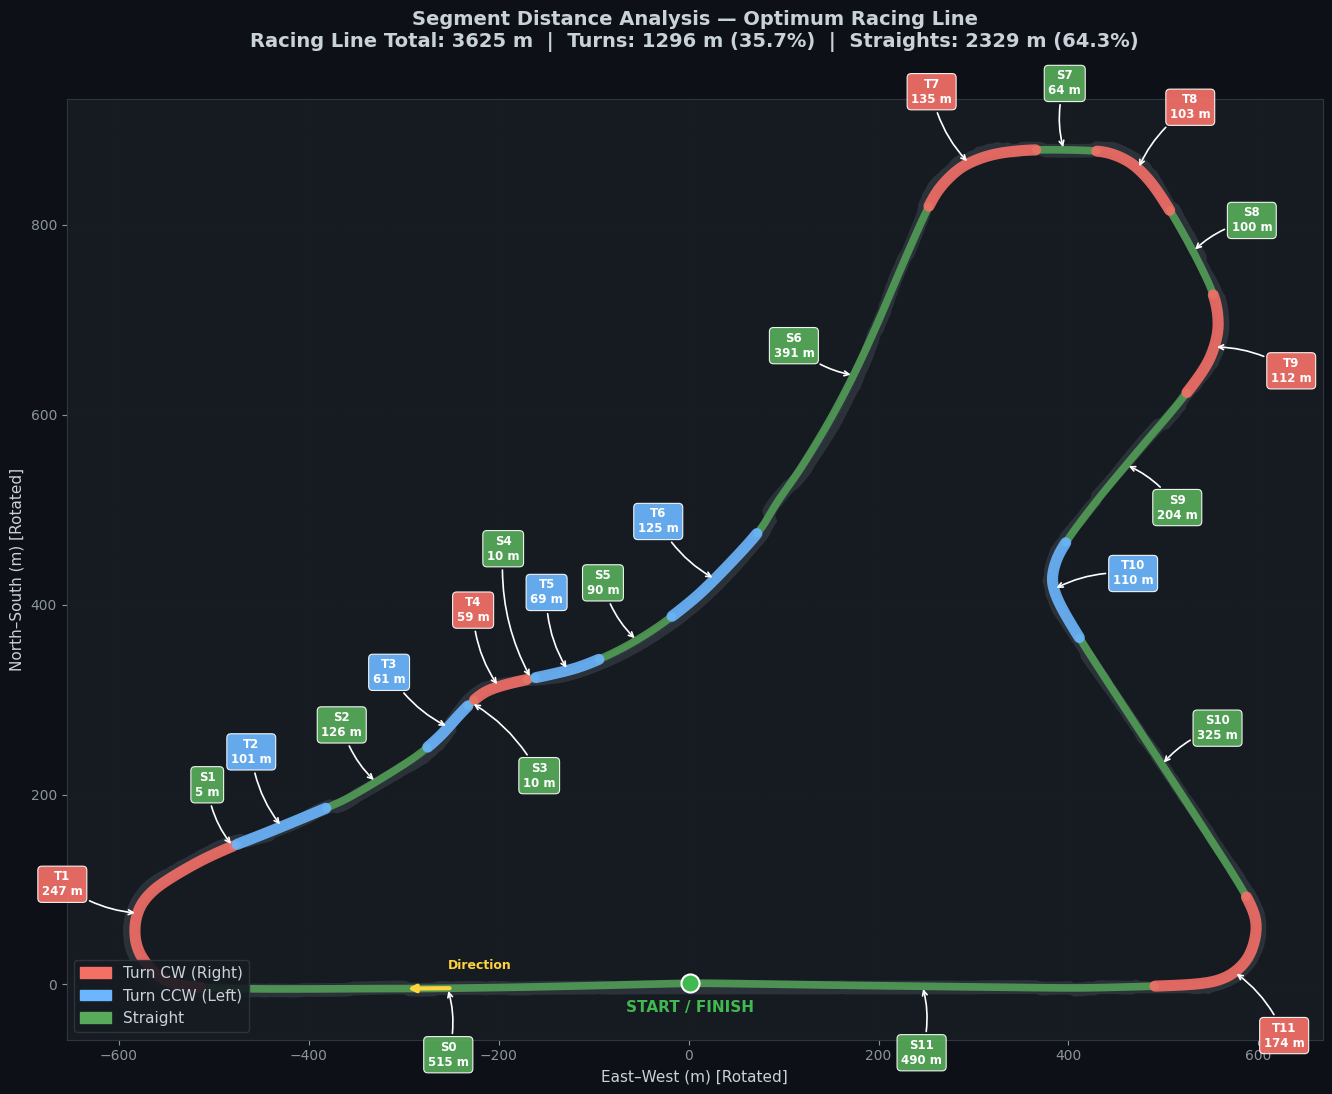

In [19]:
# ── 9.2 Distance Map — Turn & Straight Labels on Optimum Racing Line ────────

# Re-use _to_map_xy, poly_x, poly_y, xC, yC from cells above
xRL, yRL = _to_map_xy(rl.lat, rl.lon)

fig, ax = plt.subplots(figsize=(20, 11))
fig.suptitle('Segment Distance Analysis — Optimum Racing Line\n'
             f'Racing Line Total: {rl_total_m:.0f} m  |  '
             f'Turns: {total_turn:.0f} m ({total_turn/rl_total_m*100:.1f}%)  |  '
             f'Straights: {total_straight:.0f} m ({total_straight/rl_total_m*100:.1f}%)',
             fontsize=14, fontweight='bold', y=0.99)

# Corridor fill
ax.fill(poly_x, poly_y, color='#2d333b', alpha=0.95, zorder=1)
# Centerline ghost
ax.plot(xC, yC, color='#484f58', lw=0.6, ls='--', alpha=0.4, zorder=2)

# Color palette
COL_CW    = '#f47067'   # turns CW (right)
COL_CCW   = '#6cb6ff'   # turns CCW (left)
COL_STR   = '#57ab5a'   # straights

# ── Plot each segment ────────────────────────────────────────────────────────
used_positions = []

for seg in segments:
    i0, i1 = seg['i0'], seg['i1']
    if i0 == i1:
        i1 = min(i1 + 1, len(xRL) - 1)
    xs = xRL[i0:i1+1]
    ys = yRL[i0:i1+1]

    if seg['type'] == 'turn':
        col = COL_CW if seg.get('direction','') == 'CW' else COL_CCW
        ax.plot(xs, ys, color=col, lw=8, alpha=0.9, zorder=4, solid_capstyle='round')
    else:
        ax.plot(xs, ys, color=COL_STR, lw=5.5, alpha=0.8, zorder=3, solid_capstyle='round')

    # ── Label at midpoint ──
    mid_idx = (i0 + i1) // 2
    mx, my = float(xRL[mid_idx]), float(yRL[mid_idx])
    dist_m = seg['distance_m']

    if seg['type'] == 'turn':
        col_bg = COL_CW if seg.get('direction','') == 'CW' else COL_CCW
        label_text = f"{seg['label']}\n{dist_m:.0f} m"
    else:
        col_bg = COL_STR
        label_text = f"{seg['label']}\n{dist_m:.0f} m"

    # Perpendicular offset from track tangent
    look = min(8, max(1, (i1 - i0) // 4))
    a_idx = max(mid_idx - look, 0)
    b_idx = min(mid_idx + look, len(xRL) - 1)
    dx = xRL[b_idx] - xRL[a_idx]
    dy = yRL[b_idx] - yRL[a_idx]
    norm = np.sqrt(dx**2 + dy**2)
    if norm > 0:
        px, py = -dy/norm, dx/norm
    else:
        px, py = 0, 1

    off_mag = 85 if seg['type'] == 'turn' else 70
    tx, ty = mx + px * off_mag, my + py * off_mag

    # Anti-overlap: check all previous label positions
    for attempt in range(4):
        overlap = False
        for (ox, oy) in used_positions:
            if np.sqrt((tx - ox)**2 + (ty - oy)**2) < 55:
                overlap = True
                break
        if not overlap:
            break
        # Try different offset directions
        off_mag += 35
        if attempt % 2 == 0:
            tx, ty = mx - px * off_mag, my - py * off_mag
        else:
            tx, ty = mx + px * off_mag, my + py * off_mag

    used_positions.append((tx, ty))

    ax.annotate(
        label_text,
        xy=(mx, my),
        xytext=(tx, ty),
        fontsize=8.5, ha='center', va='center', color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor=col_bg, alpha=0.92,
                  edgecolor='white', linewidth=0.8),
        arrowprops=dict(arrowstyle='->', color='white', lw=1.2,
                        connectionstyle='arc3,rad=0.15'),
        zorder=10,
    )

# ── Start/Finish ──
ax.plot(xRL[0], yRL[0], 'o', color='#3fb950', ms=13, zorder=8,
        markeredgecolor='white', markeredgewidth=1.5)
ax.annotate('START / FINISH', xy=(xRL[0], yRL[0] - 30), ha='center',
            color='#3fb950', fontweight='bold', fontsize=11)

# ── Direction arrow ──
arrow_i = 50
ax.annotate('', xy=(xRL[arrow_i+10], yRL[arrow_i+10]),
            xytext=(xRL[arrow_i], yRL[arrow_i]),
            arrowprops=dict(arrowstyle='->', color='#ffd33d', lw=3))
ax.text(xRL[arrow_i+5] + 20, yRL[arrow_i+5] + 20, 'Direction',
        color='#ffd33d', fontsize=9, fontweight='bold')

# ── Legend ──
pCW  = mpatches.Patch(color=COL_CW,  label='Turn CW (Right)')
pCCW = mpatches.Patch(color=COL_CCW, label='Turn CCW (Left)')
pSTR = mpatches.Patch(color=COL_STR, label='Straight')
ax.legend(handles=[pCW, pCCW, pSTR], loc='lower left', fontsize=11, framealpha=0.9)

ax.set_xlabel('East–West (m) [Rotated]', fontsize=11)
ax.set_ylabel('North–South (m) [Rotated]', fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('../assets/plot_segment_distances.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()


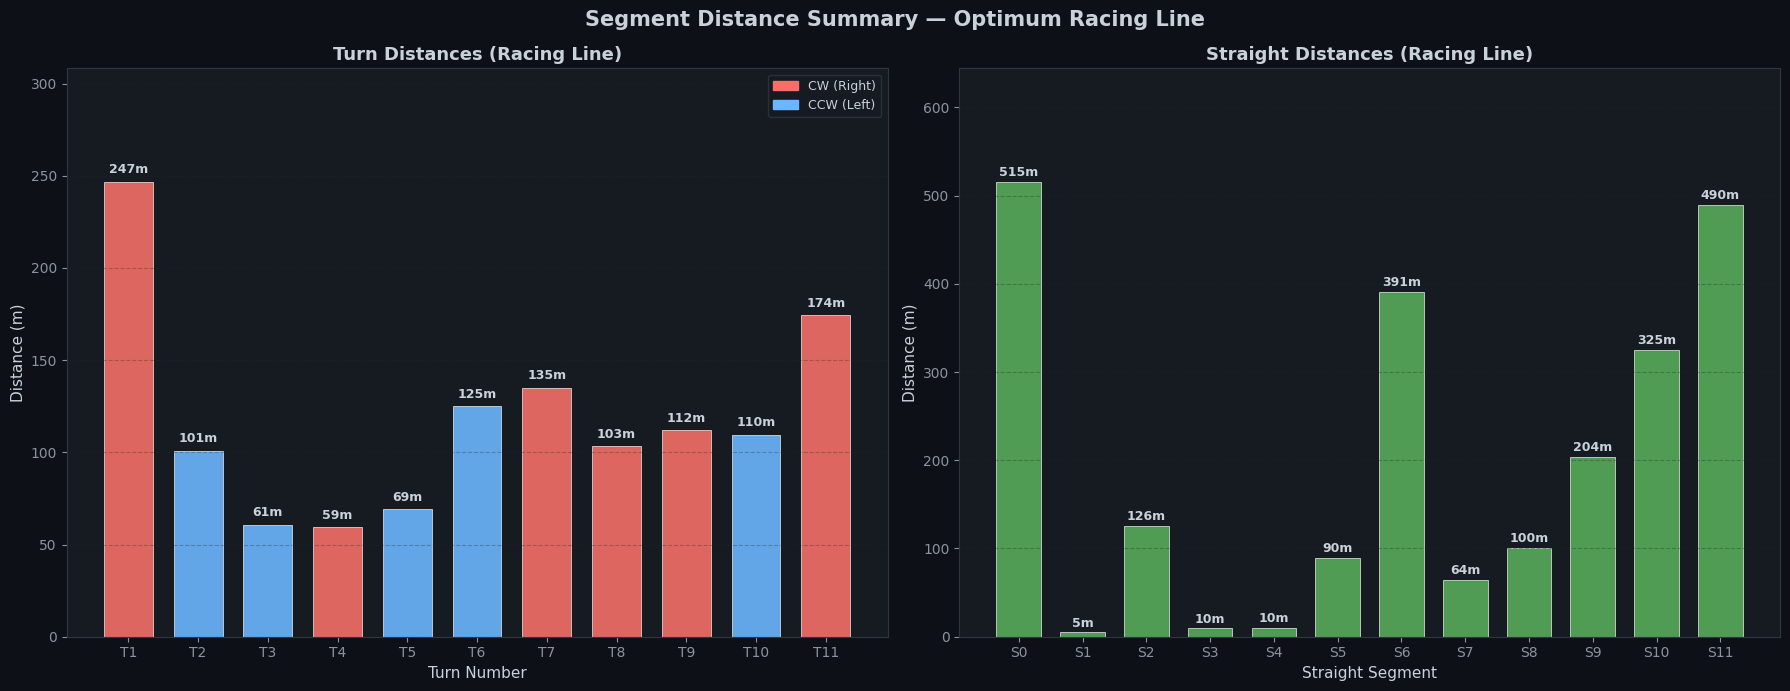

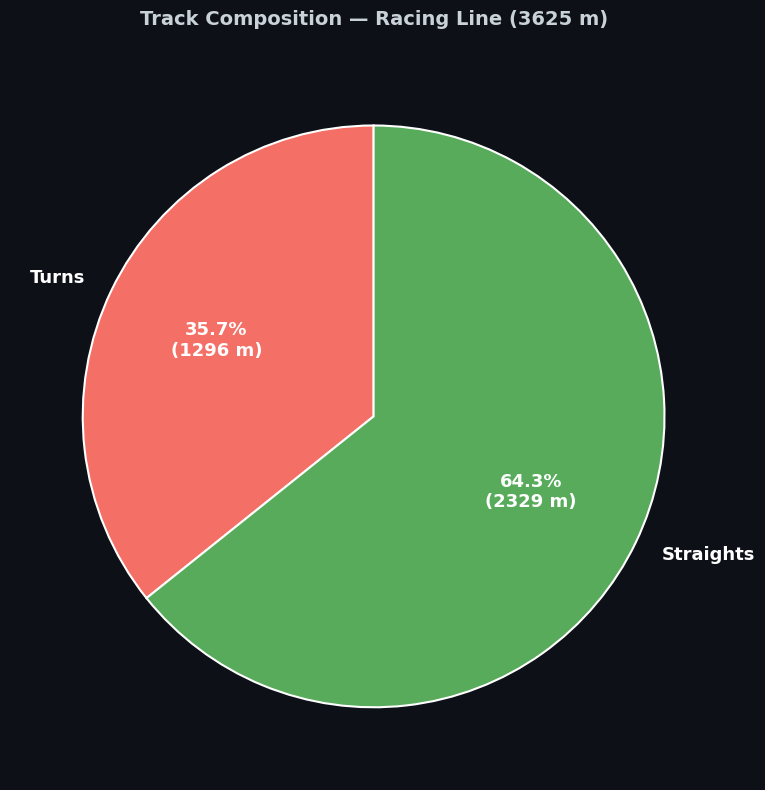

In [20]:
# ── 9.3 Distance Summary Charts ─────────────────────────────────────────────

turn_segs = [s for s in segments if s['type'] == 'turn']
str_segs  = [s for s in segments if s['type'] == 'straight']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Segment Distance Summary — Optimum Racing Line',
             fontsize=15, fontweight='bold')

# ── Left: Turn distances ──
labels_t = [s['label'] for s in turn_segs]
dists_t  = [s['distance_m'] for s in turn_segs]
colors_t = [COL_CW if s.get('direction','')=='CW' else COL_CCW for s in turn_segs]

bars1 = ax1.bar(labels_t, dists_t, color=colors_t, edgecolor='white', linewidth=0.5,
               alpha=0.9, width=0.7)
ax1.set_title('Turn Distances (Racing Line)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Distance (m)', fontsize=11)
ax1.set_xlabel('Turn Number', fontsize=11)
for bar, d in zip(bars1, dists_t):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{d:.0f}m', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_ylim(0, max(dists_t) * 1.25)
ax1.grid(axis='y', alpha=0.3)
pCW_  = mpatches.Patch(color=COL_CW,  label='CW (Right)')
pCCW_ = mpatches.Patch(color=COL_CCW, label='CCW (Left)')
ax1.legend(handles=[pCW_, pCCW_], fontsize=9)

# ── Right: Straight distances ──
labels_s = [s['label'] for s in str_segs]
dists_s  = [s['distance_m'] for s in str_segs]

bars2 = ax2.bar(labels_s, dists_s, color=COL_STR, edgecolor='white', linewidth=0.5,
               alpha=0.9, width=0.7)
ax2.set_title('Straight Distances (Racing Line)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Distance (m)', fontsize=11)
ax2.set_xlabel('Straight Segment', fontsize=11)
for bar, d in zip(bars2, dists_s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{d:.0f}m', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_ylim(0, max(dists_s) * 1.25)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/plot_segment_distance_bars.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

# ── Pie chart: Turn vs Straight proportion ──
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    [total_turn, total_straight],
    labels=['Turns', 'Straights'],
    colors=[COL_CW, COL_STR],
    autopct=lambda p: f'{p:.1f}%\n({p*rl_total_m/100:.0f} m)',
    startangle=90,
    textprops={'fontsize': 13, 'fontweight': 'bold', 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.6,
)
ax.set_title(f'Track Composition — Racing Line ({rl_total_m:.0f} m)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../assets/plot_segment_pie.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
